### Importación datos preprocesados y librerías

In [1]:
# ==============================
# Instalación de dependencias
# ==============================
import sys
# Librerías base de análisis de datos, ML, visualización y explicabilidad
# Incluye imbalanced-learn para oversampling
!{sys.executable} -m pip install pandas numpy scikit-learn statsmodels seaborn matplotlib datasets imbalanced-learn shap lime plotly

# ==============================
# Manipulación y análisis de datos
# ==============================
import pandas as pd          # Análisis y manipulación de datos tabulares
import numpy as np           # Operaciones numéricas y vectorizadas

# ==============================
# Preprocesamiento y selección de variables
# ==============================
from sklearn.preprocessing import normalize               # Normalización de datos
from sklearn.preprocessing import MinMaxScaler            # Escalado de variables a [0,1]
from sklearn.feature_selection import SelectKBest, f_classif  # Selección de variables relevantes

# ==============================
# Modelado estadístico clásico
# ==============================
import statsmodels.api as sm # Modelos estadísticos e inferencia (coeficientes, p-values)

# ==============================
# Visualización estática
# ==============================
import matplotlib.pyplot as plt        # Gráficos base
import seaborn as sns                  # Visualización estadística de alto nivel
import matplotlib.patches as mpatches  # Elementos gráficos personalizados
plt.style.use('bmh')                   # Estilo visual consistente para el notebook

# ==============================
# Visualización interactiva
# ==============================
import plotly.graph_objects as go          # Gráficos interactivos avanzados
from plotly.subplots import make_subplots  # Subplots interactivos
import plotly.express as px                # Gráficos interactivos rápidos

# ==============================
# Machine Learning (scikit-learn)
# ==============================
import sklearn as sk                       # Framework general de ML

# Separación de datos
from sklearn.model_selection import train_test_split  # Train / test split

# Modelos supervisados
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Modelos no supervisados
from sklearn.cluster import KMeans        # Segmentación / arquetipos de clientes

# ==============================
# Evaluación de modelos (métricas)
# ==============================
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,  # Matriz de confusión
    accuracy_score,                             # Accuracy global
    precision_score,                            # Precisión (eficiencia comercial)
    recall_score,                               # Recall (detección de oportunidades)
    f1_score,                                   # Balance precisión–recall
    roc_auc_score,                              # Capacidad discriminatoria
    roc_curve, auc, RocCurveDisplay             # Curva ROC y AUC
)

# ==============================
# Validación y optimización de modelos
# ==============================
from sklearn.model_selection import RandomizedSearchCV  # Búsqueda de hiperparámetros
from scipy.stats import uniform, loguniform, randint   # Distribuciones para Random Search

# ==============================
# Explicabilidad de modelos
# ==============================
import shap                              # Explicabilidad global y local basada en SHAP
shap.initjs()                             # Visualización interactiva en notebook

import lime
import lime.lime_tabular                 # Explicabilidad local basada en perturbaciones
from IPython.display import display, HTML # Renderizado de explicaciones interactivas

# ==============================
# Datasets externos
# ==============================
from datasets import load_dataset        # Carga de datasets desde Hugging Face

# ==============================
# Persistencia de modelos
# ==============================
import joblib                            # Guardado y carga eficiente de modelos


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
sys.path.append(r"H:\Cristina\Mis documentos\Github\TFM-1-Clasificacion_leads\src")

from data_loading import load_telco_data
df = load_telco_data()

In [3]:
%run "H:\Cristina\Mis documentos\Github\TFM-1-Clasificacion_leads\src\preprocessing.py"

df = preprocess_data(df)

print("Columnas finales:", df.shape)
print(df.columns.tolist())

Variables eliminadas por correlación: ['Total Revenue Log', 'Referred a Friend', 'Total Charges Log', 'Married']
Columnas finales: (7043, 34)
['Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Churn', 'CLTV', 'Dependents', 'Device Protection Plan', 'Internet Service', 'Multiple Lines', 'Online Backup', 'Online Security', 'Paperless Billing', 'Phone Service', 'Premium Tech Support', 'Satisfaction Score', 'Streaming Movies', 'Tenure in Months', 'Under 30', 'Unlimited Data', 'Total Long Distance Charges Capped', 'Total Long Distance Charges Log', 'Contract_One Year', 'Contract_Two Year', 'Customer Status_Joined', 'Customer Status_Stayed', 'Gender_Male', 'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'Number Dependents Grouped_1-2', 'Number Dependents Grouped_3-4', 'Number Dependents Grouped_5+', 'Referrals Grouped_1', 'Referrals Grouped_2+', 'Total Extra Data Charges Category_Less', 'Total Extra Data Charges Category_no charge']


In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df

,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,CLTV,Dependents,Device Protection Plan,Internet Service,Multiple Lines,Online Backup,Online Security,Paperless Billing,Phone Service,Premium Tech Support,Satisfaction Score,Streaming Movies,Tenure in Months,Under 30,Unlimited Data,Total Long Distance Charges Capped,Total Long Distance Charges Log,Contract_One Year,Contract_Two Year,Customer Status_Joined,Customer Status_Stayed,Gender_Male,Payment Method_Credit Card,Payment Method_Mailed Check,Number Dependents Grouped_1-2,Number Dependents Grouped_3-4,Number Dependents Grouped_5+,Referrals Grouped_1,Referrals Grouped_2+,Total Extra Data Charges Category_Less,Total Extra Data Charges Category_no charge
0,4,19.44,0,4849,0,1,1,0,1,0,0,1,0,3,1,25,0,1,486.00,6.188264,0,1,0,1,0,0,0,0,0,0,1,0,0,1
1,59,45.62,0,3715,0,1,1,1,0,0,0,1,1,3,0,35,1,1,1596.70,7.376320,0,0,0,1,1,0,0,0,0,0,0,0,0,1
2,0,16.07,0,5092,0,0,0,0,0,0,0,1,0,5,0,46,0,0,739.22,6.606947,0,0,0,1,1,0,0,0,0,0,0,1,0,1
3,27,0.00,0,2068,0,1,1,0,1,0,1,0,0,4,1,27,1,0,0.00,0.000000,1,0,0,1,1,1,0,0,0,0,0,1,1,0
4,21,17.22,1,4026,0,1,1,0,1,1,0,1,0,2,0,58,0,1,998.76,6.907515,1,0,0,0,1,1,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,12,10.67,0,4847,0,1,1,1,0,0,0,1,0,4,1,29,0,1,309.43,5.737958,0,0,0,1,0,0,0,0,0,0,0,0,0,1
7039,30,30.44,0,5470,0,1,1,0,0,0,0,1,0,3,1,59,0,1,1795.96,7.493852,0,1,0,1,0,0,0,0,0,0,0,0,0,1
7040,24,4.51,0,4471,0,1,1,1,0,1,0,1,1,4,1,61,0,1,275.11,5.620799,0,1,0,1,0,1,0,0,0,0,0,0,0,1
7041,24,47.06,0,5445,0,1,1,0,0,1,1,1,0,3,0,30,0,1,1411.80,7.253329,0,1,0,1,1,0,1,0,0,0,0,0,0,1


### Separación de datos

Para asegurar que el modelo pueda generalizar correctamente, se divide el dataset en conjunto de entrenamiento (80%) y conjunto de prueba (20%). Esta proporción es habitual porque permite entrenar con suficientes datos mientras se reserva una parte significativa para evaluar el desempeño del modelo en datos no vistos.

Se utiliza un random_state fijo para que la división sea reproducible, de modo que cada ejecución del notebook genere la misma separación de datos, facilitando la comparación de resultados y la depuración.

In [6]:
X = df.drop(columns=['Streaming Movies'])
y = df['Streaming Movies']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
print(len(X_train), len(X_test), len(y_train), len(y_test))

5634 1409 5634 1409


### Balanceo de clases

En este apartado comprobaremos si hay o no desequilibrio entre categorías, para así asegurarnos que el modelo aprenda de manera equitativa tanto de casos positivos como negativos.

In [8]:
df['Streaming Movies'].value_counts(normalize=True)

Streaming Movies
0    0.612097
1    0.387903
Name: proportion, dtype: float64

Vemos que hay una proporción mucho mayor de clientes que no tienen contratado el servicio de Streaming Movies (0 → 61%) que los que sí lo tienen contratado (1 → 39%).

La desproporción no es extrema, pero suficiente para afectar a nuestra predicción.

Se hará oversampling porque la clase minoritaria (1 → 38%) no es demasiado pequeña y no quieres perder datos de la clase mayoritaria.

In [9]:
#Oversampling en train
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = oversampler.fit_resample(X_train, y_train)

print(y_train_over.value_counts())

Streaming Movies
1    3440
0    3440
Name: count, dtype: int64


No haremos oversampling en test, ya que deben ser representativos de la realidad, y los datos vienen desbalanceados.

### Escalado

Se escaló mediante MinMaxScaler para normalizar las variables, llevando sus valores al rango de 0 a 1, evitando que diferencias de escala entre variables influyan indebidamente en el modelo.

In [10]:
escalado = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    escalado.fit_transform(X_train_over),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    escalado.transform(X_test),
    columns=X_test.columns
)

y_train_scaled = y_train_over.reset_index(drop=True)
y_test_scaled = y_test.reset_index(drop=True)

In [11]:
X_train_scaled.describe() #Mínimo 0 y máximo 1

,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,CLTV,Dependents,Device Protection Plan,Internet Service,Multiple Lines,Online Backup,Online Security,Paperless Billing,Phone Service,Premium Tech Support,Satisfaction Score,Tenure in Months,Under 30,Unlimited Data,Total Long Distance Charges Capped,Total Long Distance Charges Log,Contract_One Year,Contract_Two Year,Customer Status_Joined,Customer Status_Stayed,Gender_Male,Payment Method_Credit Card,Payment Method_Mailed Check,Number Dependents Grouped_1-2,Number Dependents Grouped_3-4,Number Dependents Grouped_5+,Referrals Grouped_1,Referrals Grouped_2+,Total Extra Data Charges Category_Less,Total Extra Data Charges Category_no charge
count,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000
mean,0.258473,0.457430,0.275581,0.540033,0.221221,0.389099,0.824419,0.457413,0.375727,0.304942,0.618459,0.902471,0.324273,0.551054,0.464721,0.205233,0.705233,0.296905,0.687870,0.229360,0.272529,0.054215,0.670203,0.502035,0.371657,0.048837,0.143459,0.075436,0.002326,0.162791,0.306977,0.054215,0.886919
std,0.245399,0.309844,0.446839,0.261837,0.415099,0.487581,0.380491,0.498219,0.484345,0.460416,0.485800,0.296698,0.468137,0.300519,0.346861,0.403901,0.455971,0.314192,0.291528,0.420452,0.445293,0.226458,0.470173,0.500032,0.483283,0.215543,0.350566,0.264113,0.048172,0.369201,0.461273,0.226458,0.316715
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.181986,0.000000,0.338893,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.500000,0.126761,0.000000,0.000000,0.031002,0.559312,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.211765,0.452591,0.000000,0.569380,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.500000,0.436620,0.000000,1.000000,0.173965,0.777589,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.329412,0.727946,1.000000,0.755893,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.750000,0.788732,0.000000,1.000000,0.494372,0.910368,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Normalización

Se aplicó normalización para ajustar la distribución de las variables y mejorar la estabilidad y rendimiento del modelo. 

De esta forma, se cambia la distribución de los datos para que todos los registros tengan la misma media y desviación estándar.

In [12]:
# Train: usamos la versión oversampled
X_train_norm = pd.DataFrame(normalize(X_train_scaled), columns=X_train_scaled.columns)
y_train_norm = y_train_scaled # Las etiquetas ya están listas

# Test: usamos la versión original escalada
X_test_norm = pd.DataFrame(normalize(X_test_scaled), columns=X_test_scaled.columns)
# Aquí usamos y_test original (directamente del split inicial, para evitar confusiones)
y_test_norm = y_test.reset_index(drop=True) 

print("Train X:", X_train_norm.shape, "y:", y_train_norm.shape)
print("Test X:", X_test_norm.shape, "y:", y_test_norm.shape)

Train X: (6880, 33) y: (6880,)
Test X: (1409, 33) y: (1409,)


In [13]:
X_train_norm.describe()

,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,CLTV,Dependents,Device Protection Plan,Internet Service,Multiple Lines,Online Backup,Online Security,Paperless Billing,Phone Service,Premium Tech Support,Satisfaction Score,Tenure in Months,Under 30,Unlimited Data,Total Long Distance Charges Capped,Total Long Distance Charges Log,Contract_One Year,Contract_Two Year,Customer Status_Joined,Customer Status_Stayed,Gender_Male,Payment Method_Credit Card,Payment Method_Mailed Check,Number Dependents Grouped_1-2,Number Dependents Grouped_3-4,Number Dependents Grouped_5+,Referrals Grouped_1,Referrals Grouped_2+,Total Extra Data Charges Category_Less,Total Extra Data Charges Category_no charge
count,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000,6880.000000
mean,0.074160,0.135153,0.090491,0.159758,0.060773,0.106694,0.243405,0.128454,0.102824,0.082680,0.182829,0.271095,0.087672,0.164308,0.129894,0.058977,0.206020,0.081239,0.201361,0.065260,0.075024,0.019227,0.193549,0.148908,0.109865,0.015674,0.039506,0.020632,0.000635,0.047259,0.084334,0.017385,0.267776
std,0.068537,0.092303,0.148578,0.076980,0.115194,0.135383,0.119238,0.142014,0.134178,0.126168,0.147609,0.099568,0.127885,0.093959,0.091500,0.117636,0.137792,0.081550,0.080332,0.120964,0.124135,0.081039,0.139964,0.151517,0.145709,0.069950,0.097430,0.072854,0.013276,0.108409,0.128079,0.073646,0.105419
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.019861,0.054664,0.000000,0.107037,0.000000,0.000000,0.241996,0.000000,0.000000,0.000000,0.000000,0.253570,0.000000,0.120975,0.042300,0.000000,0.000000,0.010014,0.176636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.252549
50%,0.060703,0.134182,0.000000,0.166797,0.000000,0.000000,0.276844,0.000000,0.000000,0.000000,0.253765,0.288678,0.000000,0.162064,0.128978,0.000000,0.262780,0.052478,0.224660,0.000000,0.000000,0.000000,0.256646,0.218170,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.289430
75%,0.099649,0.208214,0.271882,0.217465,0.000000,0.256122,0.315845,0.271016,0.254682,0.241318,0.304088,0.325099,0.244819,0.224701,0.215701,0.000000,0.305415,0.137161,0.251311,0.000000,0.231057,0.000000,0.298046,0.293690,0.267374,0.000000,0.000000,0.000000,0.000000,0.000000,0.244714,0.000000,0.325592
max,0.441061,0.431291,0.528888,0.435466,0.415549,0.482982,0.522407,0.445287,0.431272,0.438541,0.482982,0.528888,0.416441,0.475296,0.367276,0.445979,0.494026,0.332153,0.377218,0.433652,0.474256,0.491895,0.480779,0.483424,0.469418,0.450688,0.415549,0.384172,0.353835,0.451076,0.438591,0.480779,0.528888


### Feature Selection

Usaremos SelectKBest con f_classif evalúa de forma individual la relación estadística entre cada variable explicativa y la variable objetivo, permitiendo reducir la dimensionalidad del dataset sin perder interpretabilidad ni introducir supuestos adicionales sobre el modelo final.

In [14]:
# SelectKBest
k = 20
selector = SelectKBest(score_func=f_classif, k=k)

# Fit y Transform en TRAIN
X_train_selected = selector.fit_transform(X_train_norm, y_train_norm)

# Solo Transform en TEST (usando la variable normalizada original)
X_test_selected = selector.transform(X_test_norm)

# Verificamos
print("Variables seleccionadas:", X_train.columns[selector.get_support()].tolist())

Variables seleccionadas: ['Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Dependents', 'Device Protection Plan', 'Internet Service', 'Multiple Lines', 'Online Backup', 'Online Security', 'Paperless Billing', 'Phone Service', 'Premium Tech Support', 'Satisfaction Score', 'Tenure in Months', 'Unlimited Data', 'Total Long Distance Charges Capped', 'Customer Status_Joined', 'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'Number Dependents Grouped_1-2', 'Total Extra Data Charges Category_no charge']


In [15]:
# 1. Aplicar selección (devuelve numpy array)
X_train_selected_np = selector.fit_transform(X_train_norm, y_train_norm)
X_test_selected_np = selector.transform(X_test_norm)

# 2. RECUPERAR NOMBRES (Crucial para SHAP/LIME)
mask = selector.get_support() # True/False de qué columnas se quedaron
feature_names_list = X_train_norm.columns[mask].tolist()

# 3. Volver a convertir a DataFrame
X_train_selected = pd.DataFrame(X_train_selected_np, columns=feature_names_list)
X_test_selected = pd.DataFrame(X_test_selected_np, columns=feature_names_list)

print("Variables seleccionadas:", feature_names_list)

Variables seleccionadas: ['Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Dependents', 'Device Protection Plan', 'Internet Service', 'Multiple Lines', 'Online Backup', 'Online Security', 'Paperless Billing', 'Phone Service', 'Premium Tech Support', 'Satisfaction Score', 'Tenure in Months', 'Unlimited Data', 'Total Long Distance Charges Capped', 'Customer Status_Joined', 'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'Number Dependents Grouped_1-2', 'Total Extra Data Charges Category_no charge']


Se aplicó SelectKBest para seleccionar las 20 variables más relevantes frente al target Streaming Movies. Esto reduce la dimensionalidad del dataset, mantiene la interpretabilidad y evita que el modelo se distraiga con variables poco informativas.

### Funciones

Se crea un DataFrame para almacenar las métricas de cada modelo y poder compararlos al final. Luego, se define una función de evaluación que calcula métricas clave como matriz de confusión, curva ROC, accuracy, precision, recall, F1 score y AUC.

In [16]:
global metricas
metricas = pd.DataFrame(columns=['algoritmo', 'accuracy', 'precision', 'recall', 'f1_score', 'auc'])
print(metricas)

Empty DataFrame
Columns: [algoritmo, accuracy, precision, recall, f1_score, auc]
Index: []


In [17]:
def get_metricas(clf, data_test, clf_test, label_range):
  global metricas
  fila = {}
  y_pred = clf.predict(data_test)
  y_prob = clf.predict_proba(data_test)
  CM = confusion_matrix(clf_test, y_pred, labels=label_range)
  ConfusionMatrixDisplay(CM, display_labels=label_range).plot()
  fpr, tpr, thresholds = roc_curve(clf_test, y_prob[:,1])
  display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc(fpr, tpr))
  display.plot()
  fila = {
      'algoritmo': clf.__class__.__name__,
      'accuracy': accuracy_score(clf_test, y_pred),
      'precision': precision_score(clf_test, y_pred),
      'recall': recall_score(clf_test, y_pred),
      'f1_score': f1_score(clf_test, y_pred),
      'auc': auc(fpr, tpr)
  }
  fila = pd.DataFrame([fila])
  if metricas.empty:
    metricas = fila
  else:
    metricas = pd.concat([metricas, fila], ignore_index=True)

También crearemos otra función que nos calcula un cross-validation (CV) del algoritmo que le pasamos para determinar, a través de *randomized search*, cuáles son los mejores hiperparámetros del modelo para nuestros datos.

In [18]:
def get_best(clf, params, cv, x, labels):
  rcv = RandomizedSearchCV(clf, params, cv=cv)
  rcv.fit(x, labels)
  return rcv.best_estimator_

## Modelos de Clasificación

En esta sección se probarán distintos algoritmos, tanto básicos como avanzados, para identificar el modelo de clasificación óptimo capaz de predecir la probabilidad de conversión de cada lead.

### Regresión Logística

La regresión logística ofrece un modelo interpretable que permite estimar directamente la probabilidad de conversión de cada lead, facilitando tanto la explicación de las predicciones como la identificación de los factores más influyentes.

In [19]:
log_reg = LogisticRegression()
params = {
    "C": uniform(0, 100), # factor de regularización, coge un conjunto de valores decimales entre 0 y 1
    "fit_intercept": [True, False],
    "solver": ['lbfgs', 'liblinear', 'newton-cg', 'sag']
}
log_reg = get_best(log_reg, params, 5, X_train_selected, y_train_norm)
print(log_reg.score(X_train_selected, y_train_norm), log_reg.score(X_test_selected, y_test_norm))
log_reg.predict_proba(X_test_selected)

0.7415697674418604 0.7444996451383961


array([[0.7333391 , 0.2666609 ],
       [0.60282849, 0.39717151],
       [0.99334607, 0.00665393],
       ...,
       [0.95702301, 0.04297699],
       [0.99191773, 0.00808227],
       [0.44794699, 0.55205301]], shape=(1409, 2))

El modelo es algo preciso con una probabilidad del 74% tanto para los datos de train como para los de test

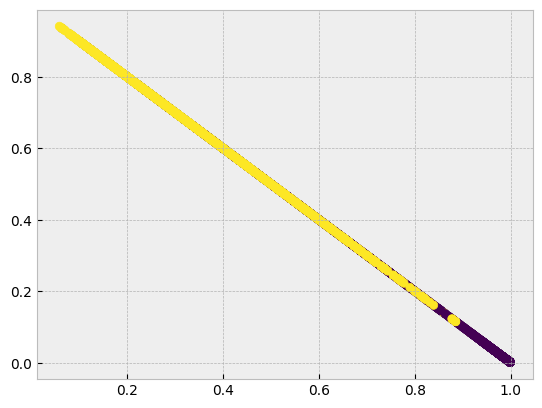

In [20]:
plt.scatter(log_reg.predict_proba(X_train_selected)[:,0], log_reg.predict_proba(X_train_selected)[:,1], c=y_train_norm)

Apenas hay mezcla de colores en el centro de la línea (zona de indecisión del 50%), lo que indica visualmente una alta robustez del modelo."

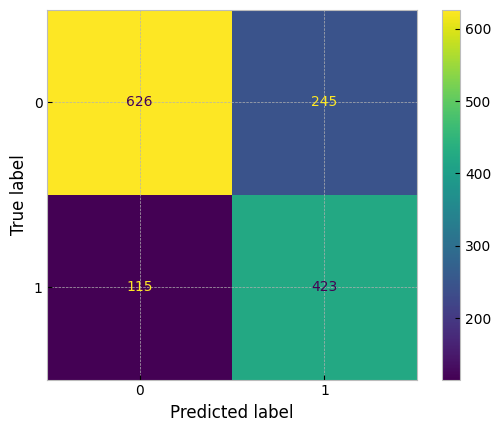

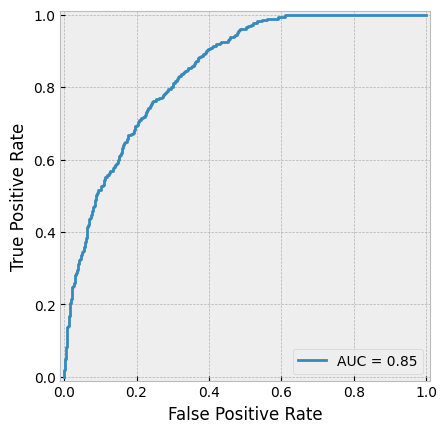

In [21]:
get_metricas(log_reg, X_test_selected, y_test_norm, [0, 1])

El AUC del modelo es de 0,85, lo que implica que tiene una gran capacidad para distinguir entre clientes que tienen y no tienen el servicio. Es decir, hay un 85% de probabilidad de que el modelo asigne una puntuación más alta a un cliente que tiene Streaming Movies frente a uno que no lo tiene. 

Detecta correctamente a 621 clientes sin el servicio y a 424 con el servicio.

Los errores son menos y equilibrados:

* 250 falsos positivos: clientes sin el servicio que podrían ser buenos candidatos para ofrecerlo.

- 114 falsos negativos: clientes con el servicio que el modelo no identificó, casos atípicos.

En general, el modelo es muy preciso y útil para identificar oportunidades de negocio.

### Naive Bayes

El modelo Naive Bayes proporciona un enfoque probabilístico simple y eficiente, especialmente útil para datos categóricos, permitiendo clasificaciones rápidas y ofreciendo una base para comparar con modelos más complejos.

Train Score: 0.7234011627906977
Test Score:  0.7281760113555713


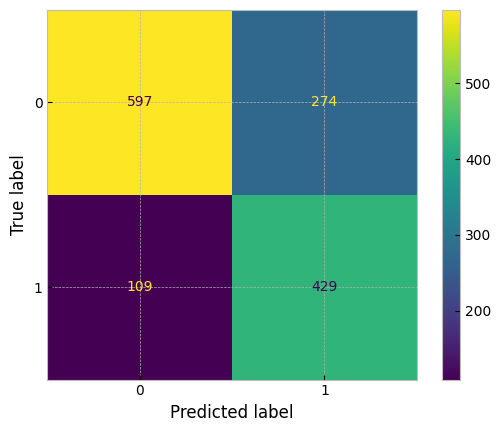

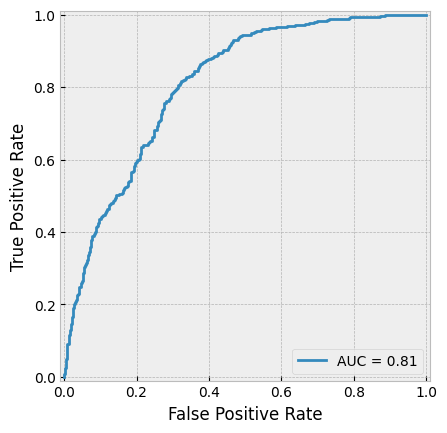

In [22]:
# Instanciamos
nb = MultinomialNB()

# Parámetros a optimizar
params = {
    "alpha": uniform(0, 1), # 'Suavizado' (Laplace/Lidstone). Evita probabilidades de 0.
    "fit_prior": [True, False] # Si aprende las probabilidades a priori de las clases o usa uniforme.
}


nb = get_best(nb, params, 5, X_train_selected, y_train_norm)

# Scores básicos
print(f"Train Score: {nb.score(X_train_selected, y_train_norm)}")
print(f"Test Score:  {nb.score(X_test_selected, y_test_norm)}")

# Métricas completas y Gráficos
get_metricas(nb, X_test_selected, y_test_norm, [0, 1])

El modelo Naive Bayes presenta un rendimiento ligeramente inferior al de otros enfoques, en parte porque asume independencia entre variables, supuesto que no se cumple en este dataset. Aun así, alcanza un 72% de accuracy, tanto en entrenamiento como en test, lo que sigue siendo un resultado sólido.

En cuanto a los errores, el modelo muestra un claro desequilibrio:

* 274 falsos positivos: clientes que el modelo predijo que contratarían el servicio, pero que finalmente no lo hicieron.

* 109 falsos negativos: clientes que sí tienen el servicio y que el modelo no detectó.

Esto indica que el modelo es optimista, con una fuerte tendencia a clasificar a los clientes como usuarios de Streaming Movies. Ante la duda, tiende a predecir que sí contratarán.

### K-Nearest Neighbours

K-Nearest Neighbours (KNN) clasifica cada observación según la mayoría de sus vecinos más cercanos, ofreciendo un enfoque intuitivo basado en similitud, aunque sensible a la escala de las variables y al ruido en los datos.

Train Score: 1.0
Test Score:  0.7246273953158269


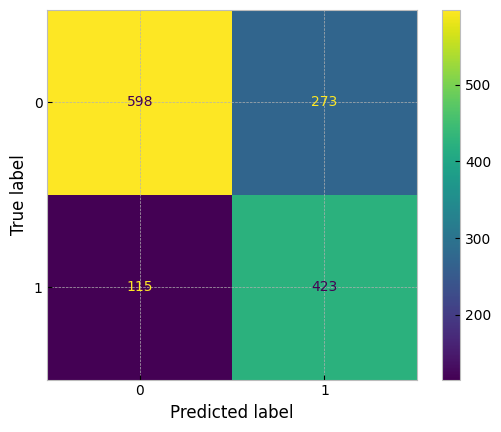

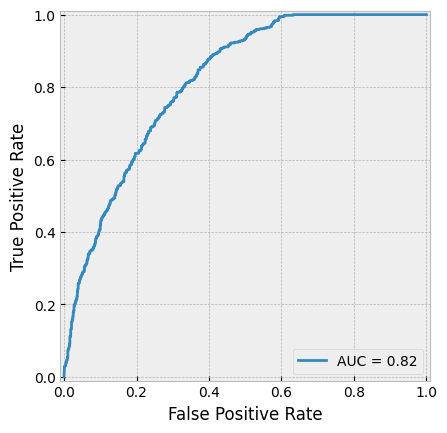

In [23]:
# 1. Instanciamos el modelo base
neigh = KNeighborsClassifier()

# 2. Definimos los parámetros a probar (OPTIMIZADOS)
params = {
    # Buscamos alrededor de 17, que fue el mejor resultado.
    "n_neighbors": [15, 16, 17, 18, 19], 
    # 'distance' fue el que te dio el mejor resultado (aunque cause Train=1.0)
    "weights": ['distance'], 
    #Alrededor de 40 fue el mejor resultado
    'leaf_size': [30, 40, 50],
    # Forzamos p=1 (Manhattan), ha dado mejor resultado que p=2 (Euclidiana)
    "p": [1] 
}

# 3. Buscamos el mejor modelo
neigh = get_best(neigh, params, 5, X_train_selected, y_train_norm)

# 4. Scores
print(f"Train Score: {neigh.score(X_train_selected, y_train_norm)}")
print(f"Test Score:  {neigh.score(X_test_selected, y_test_norm)}")

# 5. Métricas completas
get_metricas(neigh, X_test_selected, y_test_norm, [0, 1])

Con K-Nearest Neighbours se observa demasiado overfitting, ya que el modelo alcanza un 100% de precisión en entrenamiento frente a un 72% en test. Este comportamiento es coherente con el uso de weights='distance', donde el modelo acierta siempre en entrenamiento por definición matemática (cada punto tiene distancia cero consigo mismo).

En el conjunto de test, el modelo comete:

* 273 falsos positivos: clientes que el modelo predijo que contratarían el servicio, pero que no lo hicieron.

* 115 falsos negativos: clientes que sí tienen el servicio, pero que el modelo no logró identificar.

En conjunto, KNN ofrece un peor rendimiento que otros modelos.

### Decision Tree

El Decision Tree divide el espacio de características en nodos basados en reglas simples, facilitando la interpretación del modelo y capturando relaciones no lineales, aunque puede sobreajustar si no se controla su profundidad.

Train Score: 0.7309593023255814
Test Score:  0.71611071682044


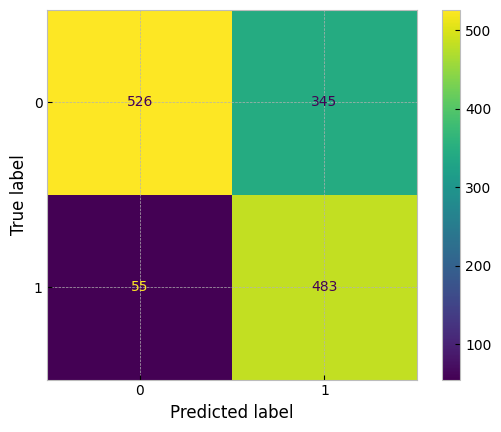

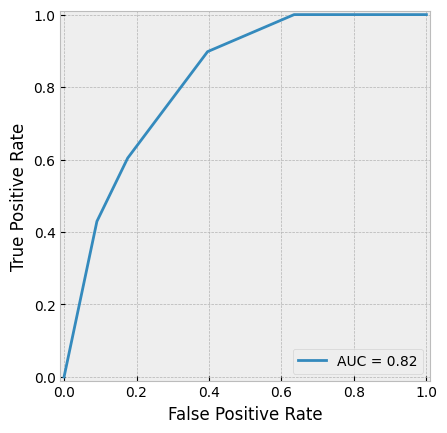

In [24]:
from scipy.stats import randint, uniform

# 1. Instanciamos con balanceo de clases automático
dtree = DecisionTreeClassifier(class_weight='balanced') 

# 2. Parámetros optimizados para evitar Overfitting
params = {
    "criterion": ['gini', 'entropy'],
    
    # Quitamos 'random' del splitter para un árbol único, 'best' suele ser más estable
    "splitter": ['best'], 
    
    # Reducimos drásticamente la profundidad. Quitamos None y 20.
    "max_depth": [3, 4, 5, 6, 8, 10], 
    
    # Aumentamos agresivamente los mínimos para dividir
    "min_samples_split": randint(20, 100), 
    
    # Obligamos a que las hojas finales tengan bastantes datos
    "min_samples_leaf": randint(10, 50),
    
    # (Opcional) Introduce aleatoriedad en las columnas para evitar depender de una sola feature
    "max_features": ['sqrt', 'log2', None],
    
    # (Avanzado) ccp_alpha es la mejor forma moderna de podar árboles. 
    # Valores pequeños > 0.0 penalizan la complejidad.
    "ccp_alpha": uniform(0.000, 0.02) 
}

# 3. Buscamos el mejor
dtree = get_best(dtree, params, 5, X_train_selected, y_train_norm)

# 4. Scores
print(f"Train Score: {dtree.score(X_train_selected, y_train_norm)}")
print(f"Test Score:  {dtree.score(X_test_selected, y_test_norm)}")
# 5. Métricas completas
get_metricas(dtree, X_test_selected, y_test_norm, [0, 1])

Con el árbol de decisión, el modelo muestra un rendimiento decente con un 74% de precisión en train y un bajo 72% en test. 

En cuanto a los errores:

* 284 falsos positivos: clientes que el modelo predijo que contratarían Streaming Movies, pero que finalmente no lo hicieron.

* 100 falsos negativos: clientes que sí tenían el servicio y que el modelo no logró detectar.

El modelo acierta en 1.025 clientes (587 sin servicio y 438 con servicio), mientras que falla en la predicción de 384 clientes.


#### Visualización

[Text(0.375, 0.875, 'x[0] <= 0.006\nentropy = 1.0\nsamples = 6880\nvalue = [3440, 3440]\nclass = 0'),
 Text(0.25, 0.625, 'entropy = 0.0\nsamples = 1209\nvalue = [1209, 0]\nclass = 0'),
 Text(0.5, 0.625, 'x[3] <= 0.103\nentropy = 0.967\nsamples = 5671\nvalue = [2231, 3440]\nclass = 1'),
 Text(0.25, 0.375, 'x[12] <= 0.05\nentropy = 0.999\nsamples = 2995\nvalue = [1558, 1437]\nclass = 0'),
 Text(0.125, 0.125, 'entropy = 0.927\nsamples = 1202\nvalue = [791.0, 411.0]\nclass = 0'),
 Text(0.375, 0.125, 'entropy = 0.985\nsamples = 1793\nvalue = [767, 1026]\nclass = 1'),
 Text(0.75, 0.375, 'x[12] <= 0.13\nentropy = 0.814\nsamples = 2676\nvalue = [673.0, 2003.0]\nclass = 1'),
 Text(0.625, 0.125, 'entropy = 0.961\nsamples = 842\nvalue = [324, 518]\nclass = 1'),
 Text(0.875, 0.125, 'entropy = 0.702\nsamples = 1834\nvalue = [349, 1485]\nclass = 1')]

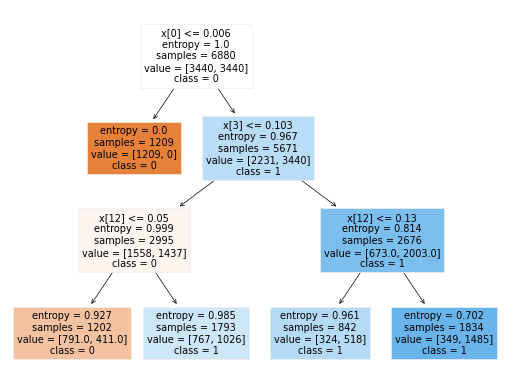

In [25]:
plot_tree(dtree, class_names = ['0','1'], filled=True)

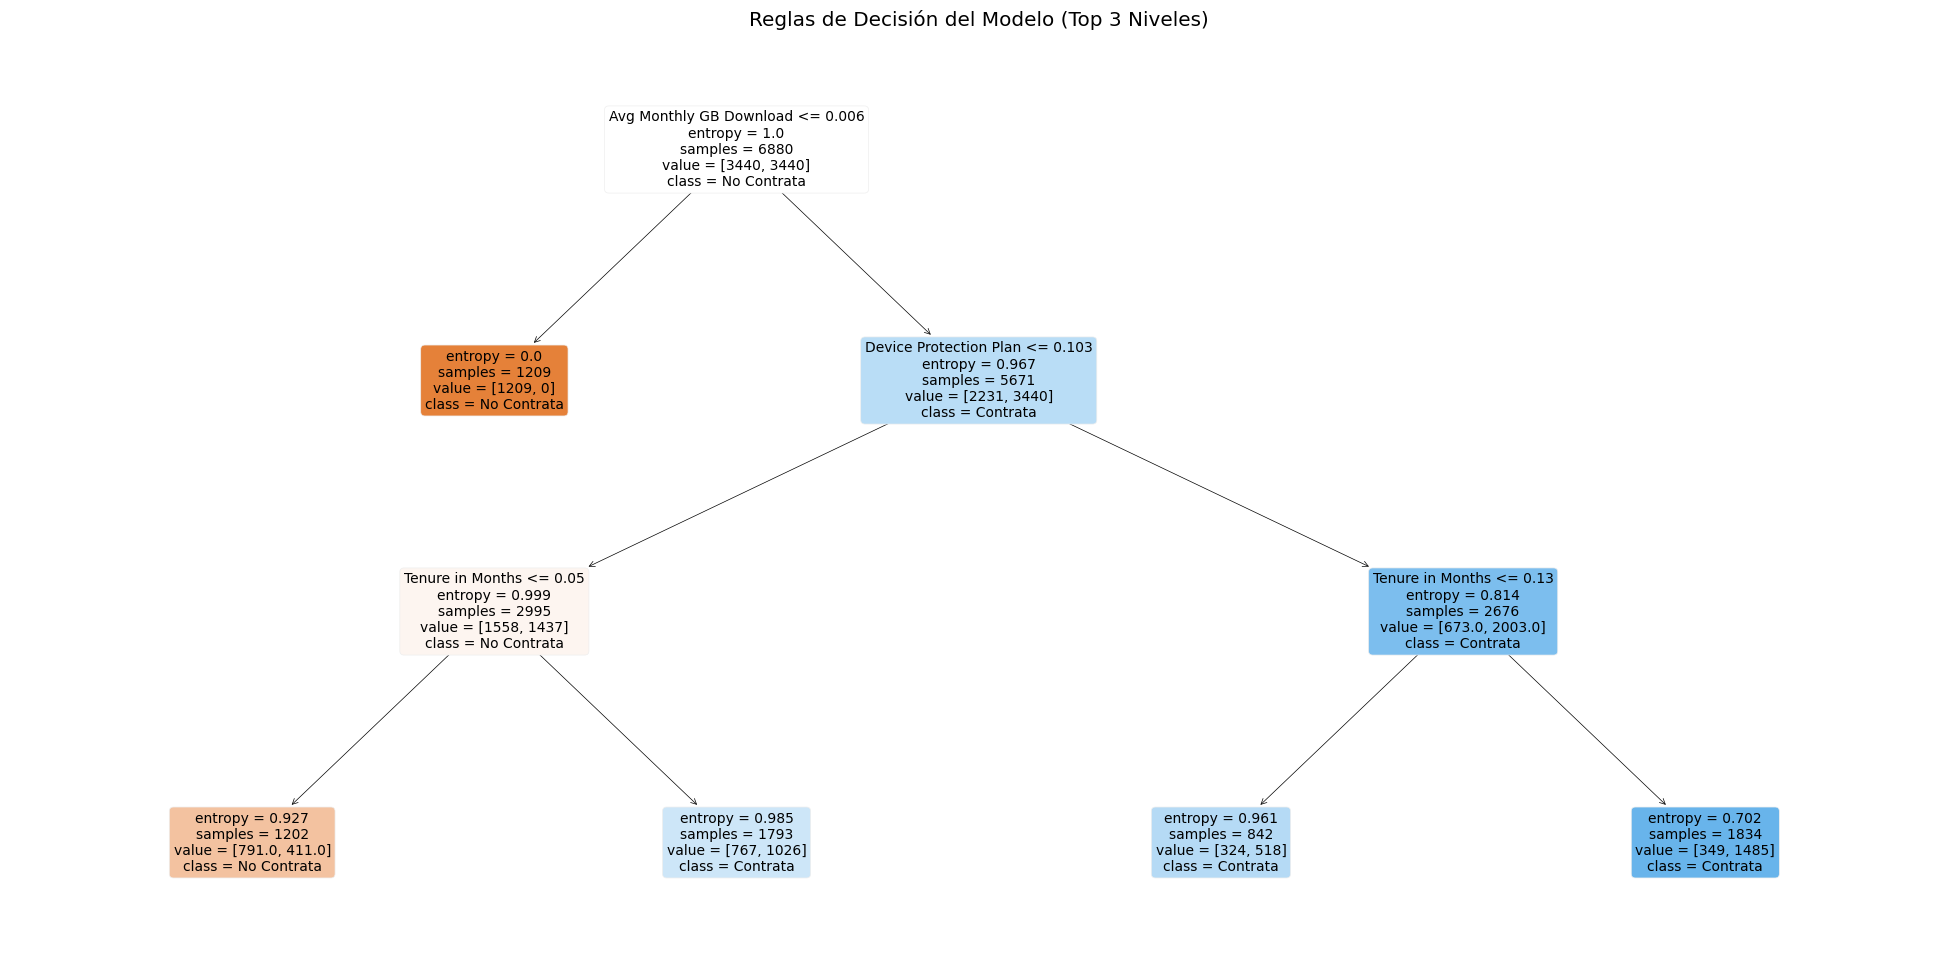

In [26]:
# Pintar el árbol
plt.figure(figsize=(25, 12))
plot_tree(
    dtree, 
    filled=True, 
    feature_names=feature_names_list, # <--- Pasamos la lista recuperada aquí
    class_names=['No Contrata', 'Contrata'], 
    rounded=True, 
    fontsize=10, 
    max_depth=3
)

plt.title("Reglas de Decisión del Modelo (Top 3 Niveles)")
plt.show()

El árbol muestra que el mejor predictor de si alguien contrata el servicio es el Avg Monthly GB Download (Promedio de descarga mensual de GB). Indica que el uso real de la red es el discriminante más fuerte: un cliente que no consume datos es fundamentalmente distinto a uno que sí. Si no hay "actividad digital", el comportamiento es predecible. Le sigue el filtro de servicios añadidos con Device Protection Plan.

- Rama Izquierda (Descarga casi nula): Si el promedio de descargas es bajísimo (<= 0.006), el modelo toma una decisión inmediata y definitiva. Llega a una hoja de pureza total (entropy = 0.0) donde concluye que el cliente NO Contrata. Son clientes inactivos, "zombies" o analógicos que, al no consumir datos, no tienen interés en el servicio.

- Rama Derecha (Descarga activa): Si el cliente sí consume datos (> 0.006), entra en juego el perfil del usuario y el modelo mira si tiene Device Protection Plan (Seguro del dispositivo). Esto sugiere que quien usa datos y además protege su equipo muestra un compromiso mayor. Dependiendo de si tienen seguro o no, el modelo luego mira la antigüedad (Tenure) para intentar separar a los que Contratan (bloques azules) de los que no.

### Stochastic Gradient Descent (SGD)

El modelo Stochastic Gradient Descent (SGD) optimiza los coeficientes de manera iterativa usando bloques de datos, permitiendo entrenar rápidamente sobre grandes volúmenes y con regularización, aunque requiere ajustar cuidadosamente la tasa de aprendizaje y el número de iteraciones.

Train Score: 0.7366279069767442
Test Score:  0.7381121362668559


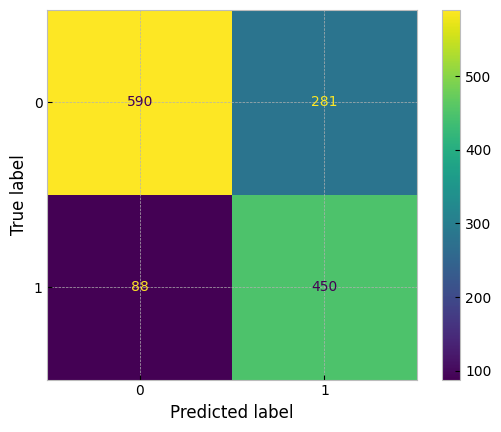

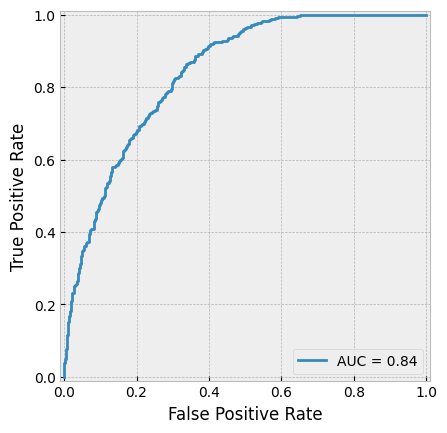

In [27]:
# 1. Instanciamos el modelo
# Ponemos random_state para que el resultado sea reproducible
sgd = SGDClassifier(random_state=42, max_iter=1000, tol=1e-3)

# 2. Parámetros a optimizar
params = {
    # Usamos estos dos porque permiten usar predict_proba para las métricas ROC/AUC
    "loss": ['modified_huber', 'log_loss'], 
    
    "penalty": ['l1', 'l2', 'elasticnet'], 
    
    # Alpha es muy sensible. Usamos escala logarítmica, exploramos desde 0.0001 hasta 10.
    'alpha': loguniform(1e-4, 1e1), 
    
    "l1_ratio": uniform(0, 1)
}

# 3. Buscamos el mejor modelo
sgd = get_best(sgd, params, 5, X_train_selected, y_train_norm)

# 4. Resultados
print(f"Train Score: {sgd.score(X_train_selected, y_train_norm)}")
print(f"Test Score:  {sgd.score(X_test_selected, y_test_norm)}")

# 5. Métricas completas
get_metricas(sgd, X_test_selected, y_test_norm, [0, 1])

Con SGD, el modelo muestra un rendimiento decente, con una precisión del 74% tanto en entrenamiento como en test, lo que indica una buena capacidad de generalización.

En cuanto a los errores:

* 99 falsos negativos: clientes con el servicio que el modelo no detectó.

* 265 falsos positivos: clientes sin el servicio que el modelo predijo como usuarios.

Además, el modelo alcanza un AUC de 0,84, lo que confirma una buena capacidad para discriminar entre clientes que tienen y no tienen Streaming Movies.

### Support vector machine

c:\Users\Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warning

Train Score: 0.7915697674418605
Test Score:  0.7288857345635202
Mejores parámetros: {'C': np.float64(3.674848139717173), 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


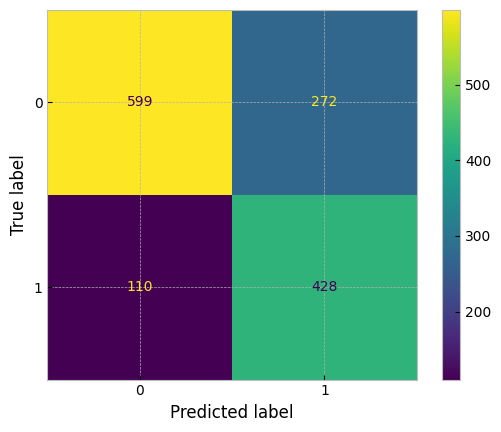

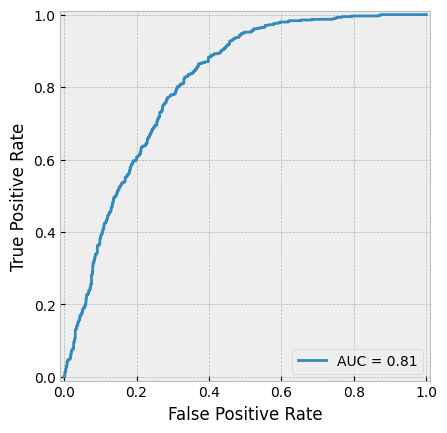

In [28]:
# 1. Instanciamos el modelo
# random_state=42 para reproducibilidad
svc = SVC(random_state=42)

# 2. Definimos los parámetros
params = {
    "C": uniform(0.1, 10), # Regularización. Cuidado: valores muy altos en SVM pueden tardar mucho.
    "kernel": ['linear', 'poly', 'rbf'], 
    
    # IMPORTANTE: probability=True hace que el entrenamiento sea más lento (aprox 5 veces más),
    # pero es OBLIGATORIO para que luego funcione tu función 'get_metricas' (curva ROC).
    'probability': [True], 
    
    # Ajustes finos para kernels no lineales
    "degree": [2, 3], # Solo afecta si elige kernel 'poly'
    "gamma": ['scale', 'auto'],
    
    # Aumentamos las iteraciones. -1 significa "hasta que converja" (recomendado)
    "max_iter": [1000, 2000, -1] 
}

# 3. Buscamos el mejor modelo
svc = get_best(svc, params, 5, X_train_selected, y_train_norm)

# 4. Resultados
print(f"Train Score: {svc.score(X_train_selected, y_train_norm)}")
print(f"Test Score:  {svc.score(X_test_selected, y_test_norm)}")
print("Mejores parámetros:", svc.get_params())

# 5. Métricas completas
get_metricas(svc, X_test_selected, y_test_norm, [0, 1])

Con Support Vector Machine, el modelo obtiene similares a los algoritmos anteriores, con la diferencia que requiere un mayor gasto computacional. Obtiene algo de overfitting con un 76% de precisión en train y 74% en test. Con un AUC de 0,83.

En cuanto a los errores:

* 93 falsos negativos: clientes con el servicio que el modelo no identificó.

* 274 falsos positivos: clientes sin el servicio que el modelo predijo como usuarios.

En conjunto, se trata de un modelo que ante la duda clasifica como un caso positivo, es uno de los modelos que más tarda en aprender y los resultados no son mucho mejores a los otros.

### Random Forest

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Train Score: 0.8040697674418604
Test Score:  0.7466288147622427
Mejores parámetros: {'bootstrap': True, 'ccp_alpha': np.float64(0.00023062425041415758), 'max_depth': 10, 'max_features': 0.3, 'max_samples': np.float64(0.7199582915145766), 'min_samples_leaf': 16, 'min_samples_split': 37, 'n_estimators': 400}


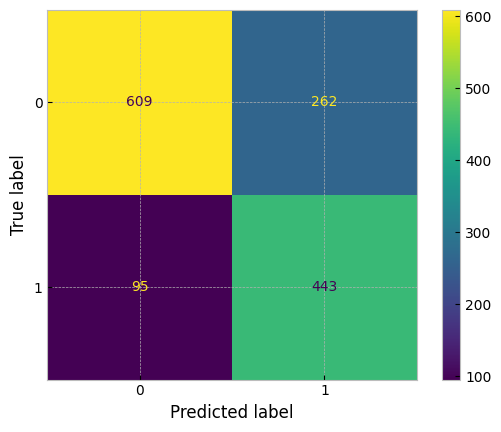

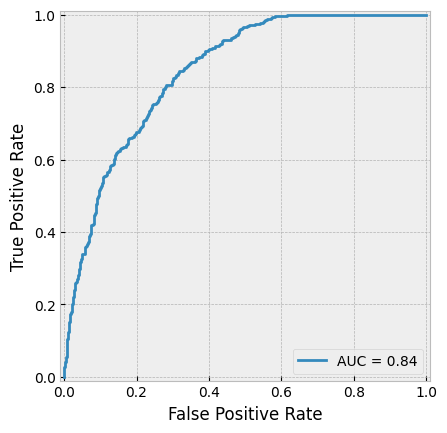

In [29]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

params = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [5, 7, 10, 12, None],
    "min_samples_leaf": randint(5, 20),
    "min_samples_split": randint(10, 40),
    "max_features": ['sqrt', 'log2', 0.3, 0.5, 0.7],
    "bootstrap": [True],            # SOLO True si usamos max_samples
    "max_samples": uniform(0.6, 0.3),  
    "ccp_alpha": uniform(0, 0.01)
}

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rs.fit(X_train_selected, y_train_norm)
rf_best = rs.best_estimator_

print(f"Train Score: {rf_best.score(X_train_selected, y_train_norm)}")
print(f"Test Score:  {rf_best.score(X_test_selected, y_test_norm)}")
print("Mejores parámetros:", rs.best_params_)

get_metricas(rf_best, X_test_selected, y_test_norm, [0, 1])


El Random Forest muestra un buen rendimiento, con un 80% de precisión en entrenamiento y un 74% en test. Esta diferencia indica overfitting, habitual en modelos basados en árboles, aunque sin comprometer la capacidad de generalización.

En cuanto a los errores, el modelo muestra:

* 95 falsos negativos: clientes con el servicio que no fueron detectados.

* 262 falsos positivos: clientes sin el servicio que el modelo clasificó como usuarios.

En conjunto, el modelo es muy preciso y estable, con un buen compromiso entre rendimiento y control del sobreajuste, lo que lo convierte en una opción sólida para este problema de clasificación.

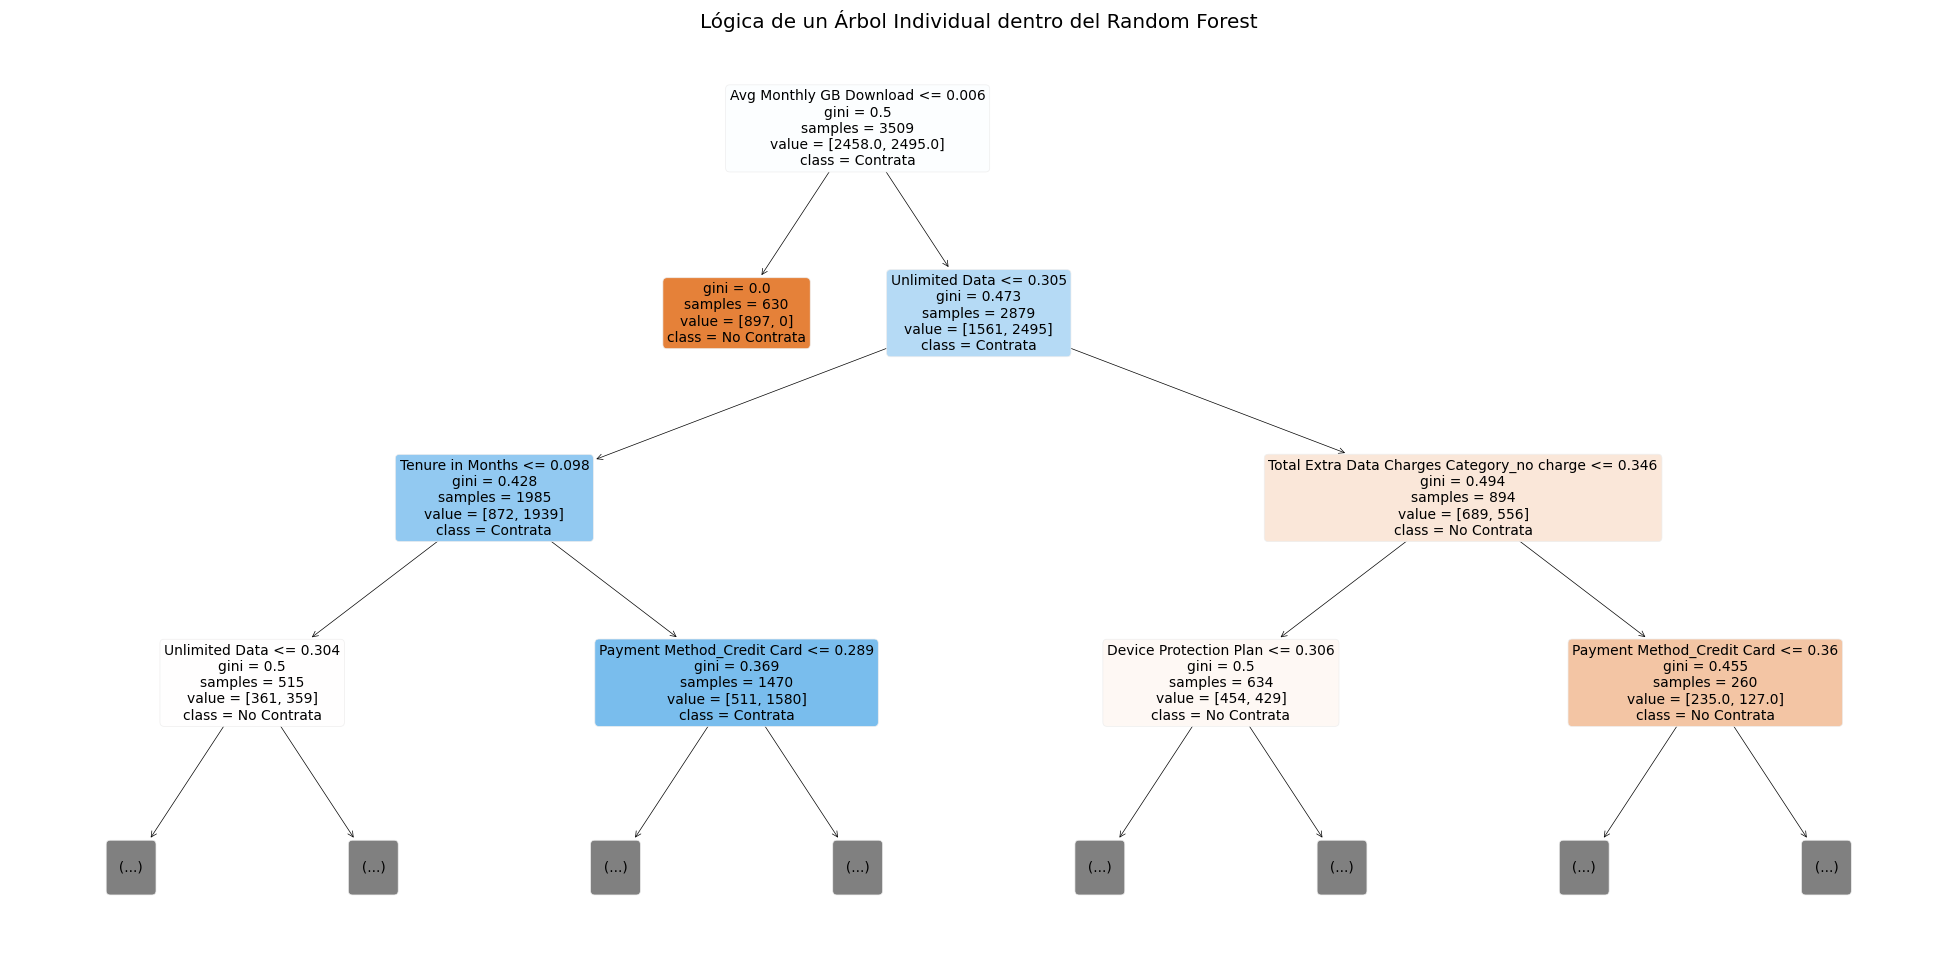

In [30]:
# Visualización del primer árbol del Random Forest entrenado
plt.figure(figsize=(25, 12))
plot_tree(
    rf_best.estimators_[0],           # Primer árbol del modelo ajustado
    filled=True, 
    feature_names=feature_names_list, # Lista con los nombres de tus features
    class_names=['No Contrata', 'Contrata'],
    rounded=True,
    max_depth=3,                      # Limitamos profundidad para que se vea bien
    fontsize=10
)
plt.title("Lógica de un Árbol Individual dentro del Random Forest")
plt.show()


El árbol comienza revisando Avg Monthly GB Download <= 0.006, es decir, identifica primero a los clientes "inactivos" que prácticamente no usan Internet. Estos se clasifican inmediatamente y con certeza absoluta (gini = 0.0) como “No Contrata”.

Entre quienes sí usan Internet (rama derecha), el árbol considera otros factores estructurales:

Unlimited Data (Datos Ilimitados): Es el siguiente gran filtro. El modelo separa a los usuarios según su tipo de tarifa de datos, lo que indica que el potencial de consumo es tan importante como el consumo real.

Antigüedad (Tenure) y Cargos Extra: Dependiendo de si tienen datos ilimitados o no, el árbol bifurca su lógica:

- Para unos, mira la Antigüedad (Tenure): separando clientes nuevos de veteranos.

 - Para otros, mira Total Extra Data Charges: identificando si el cliente está dispuesto a pagar sobrecostes, lo cual denota una alta demanda de servicio.

Método de Pago y Protección: En los niveles inferiores, refina la búsqueda mirando si usan Tarjeta de Crédito (perfil financiero) o si tienen Device Protection Plan (compromiso con el dispositivo). Esto ayuda a decidir en los casos más dudosos.

En general, este árbol muestra cómo el Random Forest profundiza más que un modelo simple. No se queda solo con el volumen de descarga, sino que cruza esa información con el tipo de contrato (Unlimited) y el comportamiento financiero (Cargos extra, Tarjeta) para perfilar al cliente con mucha más precisión.

### Gradient Boosting

Gradient Boosting combina múltiples árboles de manera secuencial, corrigiendo los errores del anterior en cada iteración, lo que suele generar un modelo muy potente y preciso, especialmente para relaciones no lineales y variables heterogéneas.

Train Score: 0.8646802325581395
Test Score:  0.7487579843860894


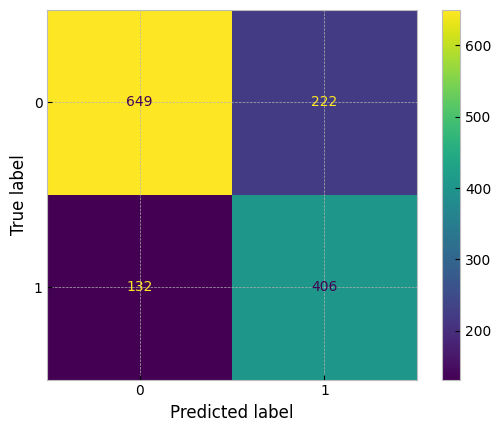

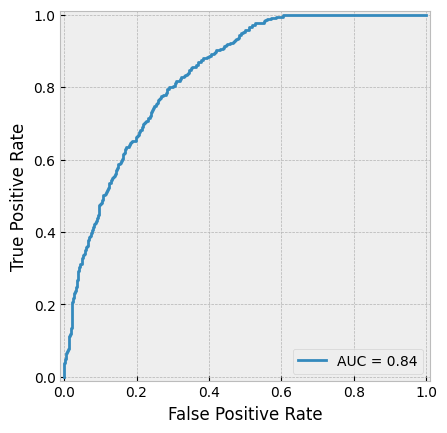

In [31]:
gbc = GradientBoostingClassifier(random_state=42)

params = {
    "learning_rate": loguniform(0.01, 0.1),
    "n_estimators": [100, 200, 300],
    "loss": ['log_loss'],  # 'exponential' puede ser inestable
    "criterion": ['friedman_mse'],
    "max_depth": [3, 4, 5],
    "min_samples_leaf": [10, 15, 20],
    "subsample": [0.7, 0.8, 0.9],
    "max_features": ['sqrt', 0.5]
}

# RandomizedSearchCV o get_best
gbc_best = get_best(gbc, params, 5, X_train_selected, y_train_norm)

print(f"Train Score: {gbc_best.score(X_train_selected, y_train_norm)}")
print(f"Test Score:  {gbc_best.score(X_test_selected, y_test_norm)}")
get_metricas(gbc_best, X_test_selected, y_test_norm, [0, 1])

Con Gradient Boosting, el modelo muestra un elevado overfitting con un 88% de precisión en entrenamiento y un 75% en test.
En cuanto a los errores:

* 139 falsos negativos: clientes con el servicio que el modelo no detectó.

* 220 falsos positivos: clientes sin el servicio que el modelo predijo como usuarios.

Aunque alcanza un AUC de 0,83, tiene demasiados casos mal clasificados y es un modelo computacionalmente costoso.

## Evalución de las métricas

In [32]:
metricas

,algoritmo,accuracy,precision,recall,f1_score,auc
0,LogisticRegression,0.744500,0.633234,0.786245,0.701493,0.846224
1,MultinomialNB,0.728176,0.610242,0.797398,0.691378,0.810204
2,KNeighborsClassifier,0.724627,0.607759,0.786245,0.685575,0.816201
3,DecisionTreeClassifier,0.716111,0.583333,0.897770,0.707174,0.820602
4,SGDClassifier,0.738112,0.615595,0.836431,0.709220,0.841395
5,SVC,0.728886,0.611429,0.795539,0.691438,0.807155
6,RandomForestClassifier,0.746629,0.628369,0.823420,0.712792,0.844233
7,GradientBoostingClassifier,0.748758,0.646497,0.754647,0.696398,0.835151


Se selecciona Random Forest como modelo final. Si bien la Regresión Logística ofrece un excelente AUC (0,845), el Random Forest logra superar a todos los modelos en F1-Score (0,712) y Accuracy (0,746), demostrando el mejor equilibrio global entre precisión y cobertura.

El factor decisivo para el negocio es su Recall superior (82,3%) frente a otras opciones avanzadas como Gradient Boosting, que se queda en un 74,1%. Esta diferencia es crítica: el Random Forest es capaz de detectar significativamente más oportunidades de compra reales, minimizando el riesgo de ignorar a un cliente interesado. El Random Forest es la herramienta más rentable para maximizar la captación de la campaña, gracias a su capacidad de modelar relaciones no lineales y mantener alta sensibilidad. Además, permite extraer la importancia de variables, proporcionando al equipo de marketing una jerarquía clara de los factores que impulsan la compra, esencial para diseñar campañas personalizadas y fundamentar decisiones de negocio

In [33]:
# Guardamos el modelo ya entrenado
joblib.dump(rf_best, 'modelo_random_forest_final.pkl')
print("¡Modelo Random Forest guardado con éxito!")

# Simulamos otro script o momento
rf_loaded = joblib.load('modelo_random_forest_final.pkl')

# Verificamos que funciona
score_cargado = rf_loaded.score(X_test_selected, y_test_norm)
print(f"Score del modelo recuperado: {score_cargado}")

¡Modelo Random Forest guardado con éxito!
Score del modelo recuperado: 0.7466288147622427


## Explicabilidad del modelo

Una vez validada la eficacia del modelo, pasamos a aplicar técnicas de explicabilidad para entender como se están realizando estas predicciones.

### Explicabilidad global

Evaluaremos la explicabilidad global del modelo para comprender su comportamiento general y obtener una visión clara de los patrones que está aprendiendo.

#### Feature importance

A continuación analizamos la feature importance para identificar qué variables tienen mayor influencia en las predicciones del modelo y entender mejor qué factores están impulsando el resultado final.

C:\Users\Cristina\AppData\Local\Temp\ipykernel_11308\2504639681.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=data_rf, x="score_rel", y="variables", palette="viridis")


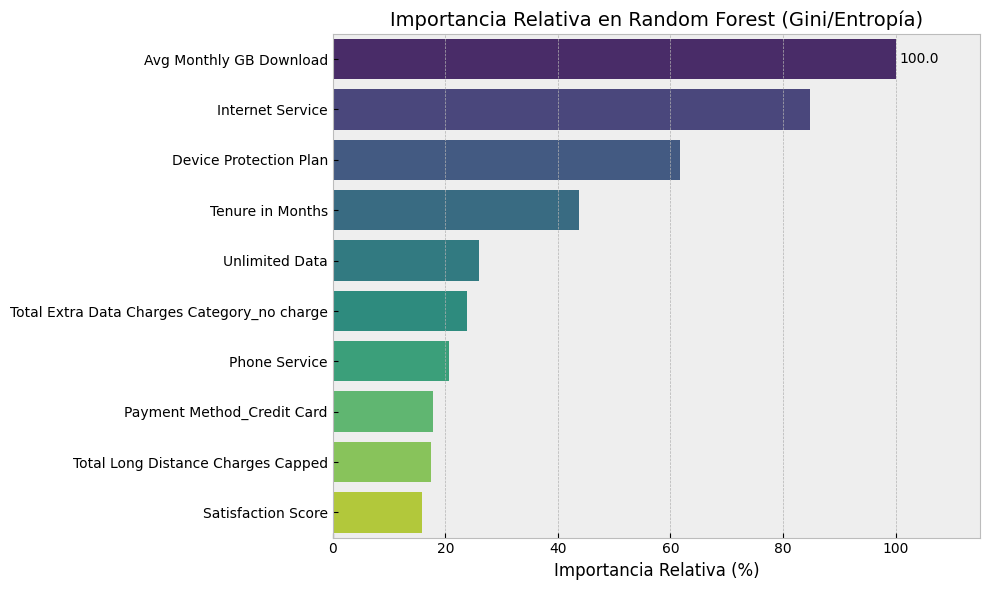

In [34]:
# 1. Extraemos la importancia nativa del Random Forest
importancias = rf_loaded.feature_importances_

# 2. Creamos el DataFrame
# Asegúrate de que feature_names_list tenga el orden correcto de columnas de X_train_selected
data_rf = pd.DataFrame({
    'variables': feature_names_list,
    'score': importancias
})

# 3. Normalizamos de 0 a 100 respecto a la más importante
max_score = data_rf['score'].max()
data_rf['score_rel'] = (data_rf['score'] / max_score) * 100
data_rf['score_rel'] = data_rf['score_rel'].round(2)

# 4. Ordenamos y cogemos el Top 10
data_rf = data_rf.sort_values(by="score_rel", ascending=False).head(10)

# 5. Visualización gráfica
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=data_rf, x="score_rel", y="variables", palette="viridis")
ax.bar_label(ax.containers[0], fontsize=10, padding=3, fmt='%.1f')

plt.title("Importancia Relativa en Random Forest (Gini/Entropía)", fontsize=14)
plt.xlabel("Importancia Relativa (%)")
plt.ylabel("")
plt.xlim(0, 115)
plt.tight_layout()
plt.show()

El Random Forest muestra que sus decisiones se apoyan en tres ejes principales:

- Consumo e Infraestructura (Top 1–2): Avg Monthly GB Download (100%) e Internet Service (~85%) son los predictores más influyentes, destacando que el uso real de datos y la disponibilidad de conexión son la base para identificar candidatos potenciales.

- Perfil de Valor y Protección (Top 3): Device Protection Plan (~62%) señala que el modelo prioriza a clientes que cuidan y aseguran sus dispositivos, reflejando un perfil tecnológico y de mayor valor.

- Fidelidad y Marco Contractual (Top 4–5): Tenure in Months (~44%) y Unlimited Data (~26%) completan el top 5, mostrando que la antigüedad y la existencia de tarifa ilimitada refuerzan la probabilidad de contratación, aunque el consumo real sigue siendo más decisivo.

Forma de vals: (1409, 20)
Cantidad de columnas en X: 20


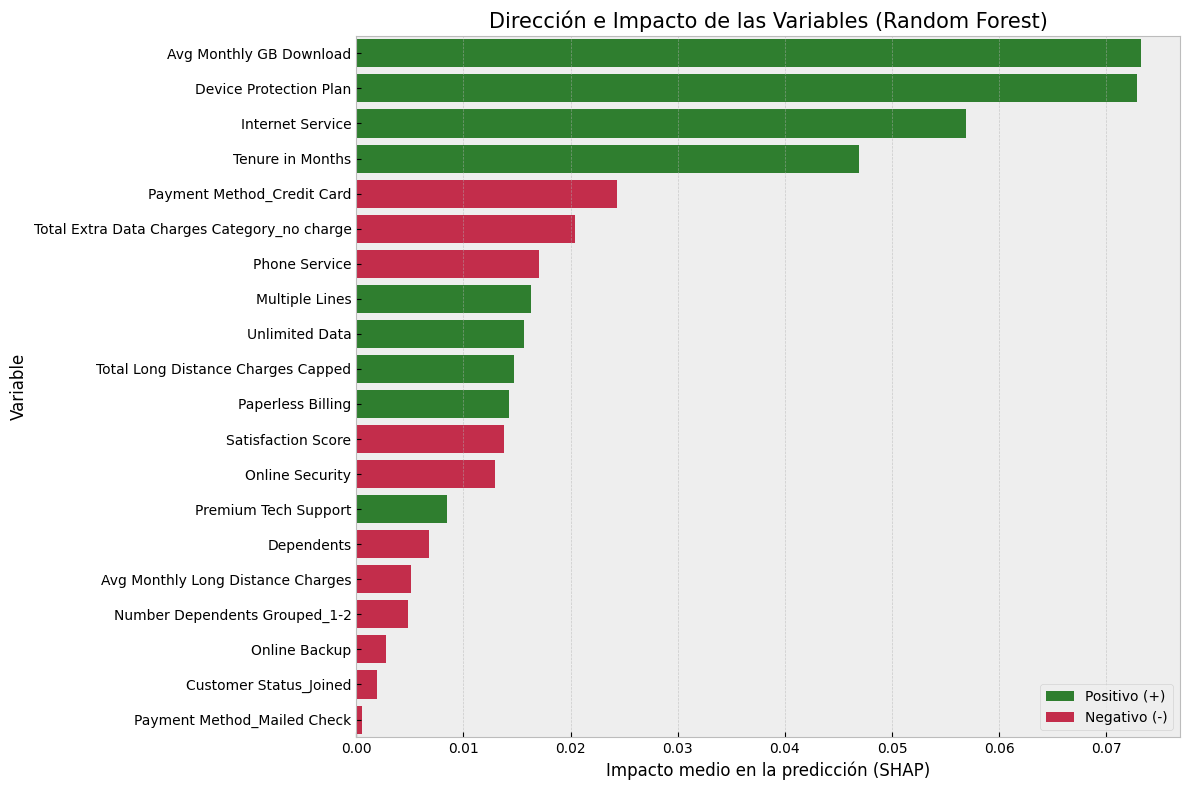

In [35]:
# 1. Calculamos SHAP values
explainer = shap.TreeExplainer(rf_loaded)
shap_values = explainer.shap_values(X_test_selected)

# 2. Corrección: Selección robusta de la Clase 1 (Positiva)
if isinstance(shap_values, list):
    vals = shap_values[1]
else:
    # Seleccionamos: Todas las filas (:), todas las columnas (:), índice de clase 1
    vals = shap_values[:, :, 1]

# 3. Verificamos dimensiones antes de crear el DataFrame (Debugging)
print(f"Forma de vals: {vals.shape}")
print(f"Cantidad de columnas en X: {len(X_test_selected.columns)}")

# 4. Ccreamos el DataFrame para el gráfico
feature_names = X_test_selected.columns
shap_summary = pd.DataFrame(vals, columns=feature_names)

# Calculamos la media del impacto absoluto
mean_abs_shap = np.abs(shap_summary).mean().sort_values(ascending=False)

# Calculamos correlación (Signo)
correlations = []
for feature in mean_abs_shap.index:
    corr = np.corrcoef(shap_summary[feature], X_test_selected[feature])[0, 1]
    correlations.append(corr)

# DataFrame final para el gráfico
df_plot = pd.DataFrame({
    'Feature': mean_abs_shap.index,
    'SHAP_mean': mean_abs_shap.values,
    'Signo': ['Positivo (+)' if c > 0 else 'Negativo (-)' for c in correlations]
})

# Top 20
df_plot = df_plot.head(20)

# Graficamos
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_plot,
    y='Feature',
    x='SHAP_mean',
    hue='Signo',
    dodge=False,
    palette={'Positivo (+)': 'forestgreen', 'Negativo (-)': 'crimson'}
)

plt.title('Dirección e Impacto de las Variables (Random Forest)', fontsize=15)
plt.xlabel('Impacto medio en la predicción (SHAP)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Al fijarnos en el signo de los coeficientes (positivo en verde y negativo en rojo), se entiende mucho mejor cómo es el “cliente ideal” para el modelo y qué factores empujan o frenan la contratación:

**Factores qué impulsa la compra (drivers positivos)**

Los usuarios con alto consumo de datos (Avg Monthly GB Download) y que protegen sus dispositivos (Device Protection Plan) son los más propensos a contratar, reforzados por una buena infraestructura (Internet Service) y antigüedad (Tenure). Hogares con múltiples líneas o planes ilimitados (Multiple Lines, Unlimited Data) también suman puntos, mostrando que la conectividad compartida y constante favorece la adopción.

**Factores que frenan la compra (drivers negativos)**

Algunos comportamientos reducen la probabilidad de venta: pagar con tarjeta de crédito (Payment Method_Credit Card), no generar cargos extra (Total Extra Data Charges Category_no charge) o contar solo con Phone Service. Además, una satisfacción muy alta o servicios de seguridad online (Satisfaction Score, Online Security) pueden actuar como frenos, indicando que los clientes más asentados o cautelosos son menos propensos a contratar streaming.

#### Shapley value globales

Para entender qué variables influyen más en el comportamiento del modelo a nivel general, utilizamos los valores de Shapley globales. Este enfoque nos permite medir la contribución media de cada característica en las predicciones, ofreciendo una visión clara y agregada de qué factores son realmente determinantes en las decisiones del modelo.

<Figure size 1800x1200 with 0 Axes>

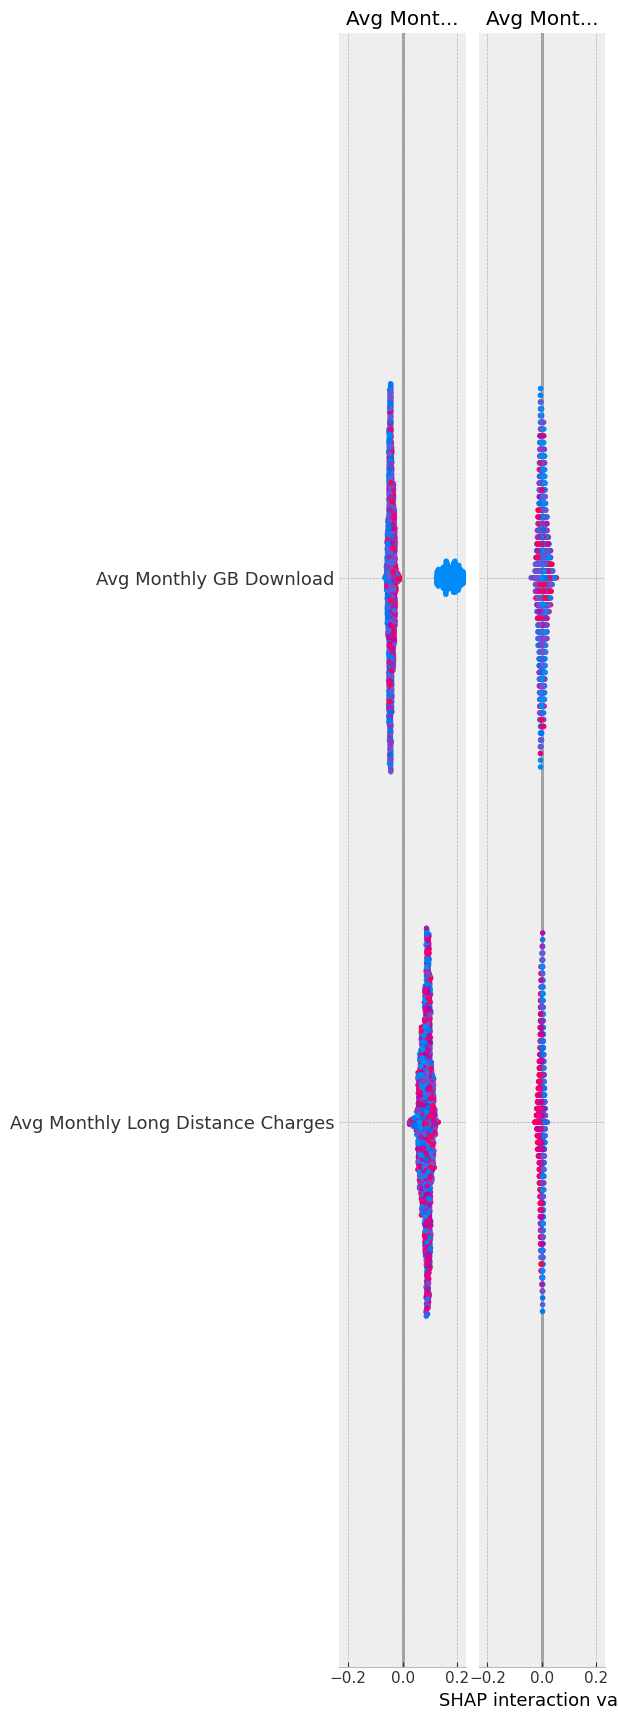

In [36]:
# TreeExplainer
explainer = shap.TreeExplainer(rf_loaded)

# Calculamos SHAP values
shap_values = explainer.shap_values(X_test_selected)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]  # Clase positiva
else:
    shap_values_class1 = shap_values

# Graficamos Summary Plot con tamaño grande y todas las variables
plt.figure(figsize=(18, 12))  # Ajusta tamaño a tu gusto

shap.summary_plot(
    shap_values_class1,
    X_test_selected,
    feature_names=feature_names_list,
    max_display=len(feature_names_list)  # Muestra todas las variables
)

El gráfico de dispersión de valores SHAP (interacciones) permite comparar cómo influyen distintas variables en el modelo:

Avg Monthly GB Download (Determinante): Muestra alta dispersión y polarización. Los puntos se extienden horizontalmente y forman dos grupos claros: un clúster de valores bajos (azules) con impacto positivo y el resto centrado o a la izquierda. Esto indica que el modelo utiliza esta variable para tomar decisiones drásticas entre clientes, siendo un factor clave.

Avg Monthly Long Distance Charges (Neutra): Los puntos se concentran casi todos sobre cero, sin dispersión horizontal. Esto refleja que esta variable aporta muy poca información y su influencia en la predicción es prácticamente nula.

Conclusión: La visualización resalta la jerarquía de importancia: el consumo de datos guía fuertemente las predicciones, mientras que los cargos de larga distancia son irrelevantes.

Para simplificar la parte matemática y que se vea más claro, hemos usado un gráfico de barras.

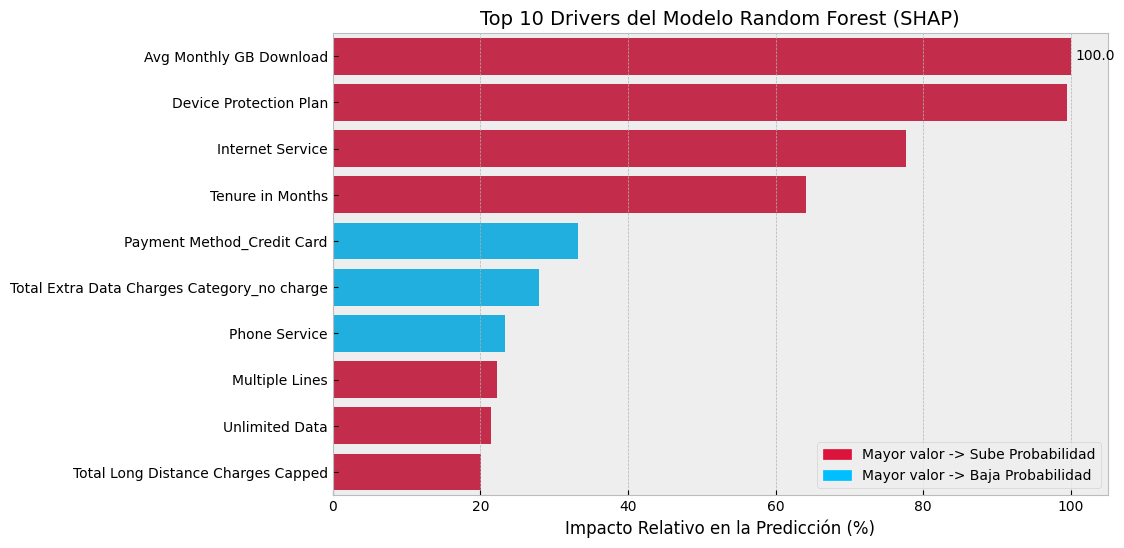

In [37]:
# 1. DataFrame de SHAP values (Clase 1)
shap_v = pd.DataFrame(shap_values_class1[:, :, 1], columns=feature_names_list)
X_test_df = pd.DataFrame(X_test_selected, columns=feature_names_list)

# 2. Calculamos correlación (Signo)
corr_list = []
for col in feature_names_list:
    # Correlación entre el valor real y su impacto SHAP
    r = np.corrcoef(shap_v[col], X_test_df[col])[0, 1]
    corr_list.append(r)

corr_df = pd.DataFrame({'Variable': feature_names_list, 'Corr': corr_list})

# 3. Asignamos color: Crimson (Positivo) vs Deepskyblue (Negativo)
corr_df['Sign'] = np.where(corr_df['Corr'] > 0, 'crimson', 'deepskyblue')

# 4. Magnitud (Importancia media absoluta)
shap_abs = np.abs(shap_v)
k = pd.DataFrame(shap_abs.mean()).reset_index()
k.columns = ['Variable', 'SHAP_abs']

# 5. Merge y Top 10
k2 = k.merge(corr_df, on='Variable', how='inner')
k2 = k2.sort_values(by='SHAP_abs', ascending=False)

# Normalizar
max_val = k2.iloc[0]['SHAP_abs']
k2['SHAP_rel'] = (k2['SHAP_abs'] / max_val) * 100
k2 = k2.head(10)

# 6. Gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=k2,
    y='Variable',
    x='SHAP_rel',
    palette=k2['Sign'].tolist(),
    hue='Variable',
    legend=False
)

ax.bar_label(ax.containers[0], fmt='%.1f', padding=3, fontsize=10)

# Leyenda manual
red_patch = mpatches.Patch(color='crimson', label='Mayor valor -> Sube Probabilidad')
blue_patch = mpatches.Patch(color='deepskyblue', label='Mayor valor -> Baja Probabilidad')
plt.legend(handles=[red_patch, blue_patch], loc='lower right')

plt.title('Top 10 Drivers del Modelo Random Forest (SHAP)', fontsize=14)
plt.xlabel('Impacto Relativo en la Predicción (%)')
plt.ylabel('')
plt.show()

Esta gráfica muestra de forma clara los factores de contratación del servicio:

**Impulsores  de compra (Barras Rojas)**

El perfil ideal combina consumo intensivo de datos (Avg Monthly GB Download) y protección del dispositivo (Device Protection Plan), con soporte de infraestructura (Internet Service) y fidelidad (Tenure in Months). Hogares con múltiples líneas o planes ilimitados también tienen más probabilidades de contratar streaming.

**Freno de compra (Barra Azul)**

Pagar con tarjeta de crédito, no generar cargos extra (Total Extra Data Charges no charge) o centrarse solo en Phone Service reduce la propensión. En resumen, el modelo favorece usuarios activos y tecnológicos, y penaliza clientes pasivos o menos digitalizados.

### Explicabilidad local

Mientras que la explicabilidad global nos ayuda a entender el comportamiento general del modelo, la explicabilidad local se centra en casos individuales. En esta sección analizamos por qué el modelo ha tomado una decisión concreta para un cliente específico, identificando qué variables han empujado la predicción hacia la compra y cuáles han actuado como freno.

Este enfoque es especialmente útil desde un punto de vista de negocio, ya que permite justificar recomendaciones concretas, entender perfiles límite y ofrecer argumentos claros y accionables para el equipo comercial.

#### Shapley values locales

Los SHAP values locales explican una predicción concreta mostrando qué variables la han impulsado o frenado. Permiten entender, de forma clara, por qué el modelo toma una decisión para un cliente específico.

In [38]:
# DataFrame con nombres de features
X_test_df = pd.DataFrame(X_test_selected, columns=feature_names_list)

# Explainer para Random Forest entrenado
explainer = shap.TreeExplainer(rf_best)  # o rf_loaded si lo cargaste de .pkl
shap_values_full = explainer.shap_values(X_test_selected)

# Para clasificación binaria tomamos la clase positiva
if isinstance(shap_values_full, list):
    shap_values = shap_values_full[1]       # Clase "Contrata"
    base_value = explainer.expected_value[1]
else:
    shap_values = shap_values_full[:, :, 1]
    base_value = explainer.expected_value[1]

# Identificamos automáticamente los casos extremos
probs = rf_best.predict_proba(X_test_selected)[:, 1]  # Probabilidades de la clase positiva
idx_exito = np.argmax(probs)   # Cliente con mayor probabilidad
idx_fracaso = np.argmin(probs) # Cliente con menor probabilidad

# --- GRÁFICO 1: CASO DE ÉXITO ---
print(f"--- ANÁLISIS LOCAL: CASO DE ÉXITO (Cliente {idx_exito}) ---")
print(f"La probabilidad predicha por el modelo es del: {probs[idx_exito]*100:.2f}%")
print("Este gráfico explica por qué el modelo está tan seguro de que comprará:")

display(shap.force_plot(
    base_value, 
    shap_values[idx_exito, :], 
    X_test_df.iloc[idx_exito, :]
))

# --- GRÁFICO 2: CASO DE RECHAZO ---
print(f"\n--- ANÁLISIS LOCAL: CASO DE RECHAZO (Cliente {idx_fracaso}) ---")
print(f"La probabilidad predicha por el modelo es del: {probs[idx_fracaso]*100:.2f}%")
print("Este gráfico explica qué factores están frenando la compra (barras azules):")

display(shap.force_plot(
    base_value, 
    shap_values[idx_fracaso, :], 
    X_test_df.iloc[idx_fracaso, :]
))


--- ANÁLISIS LOCAL: CASO DE ÉXITO (Cliente 375) ---
La probabilidad predicha por el modelo es del: 92.97%
Este gráfico explica por qué el modelo está tan seguro de que comprará:



--- ANÁLISIS LOCAL: CASO DE RECHAZO (Cliente 1176) ---
La probabilidad predicha por el modelo es del: 0.04%
Este gráfico explica qué factores están frenando la compra (barras azules):


Los gráficos de fuerza confirman que el Random Forest toma decisiones coherentes y alineadas con el negocio, identificando correctamente clientes con alto y bajo potencial.

**1. Cliente de alto potencial (Cliente 375 – Probabilidad: 93%)**

El modelo está prácticamente seguro de que contratará.

Combina tres factores clave: consumo de datos elevado, internet disponible y protección de dispositivos.

La antigüedad del cliente refuerza su probabilidad.

Conclusión: Este cliente tiene un alto perfil tecnológico, fiel y de alto valor para la empresa.

**2. Cliente de bajo potencial (Cliente 1176 – Probabilidad: 0,04%)**

El modelo descarta correctamente a este cliente.

No tiene internet, no consume datos y no protege sus dispositivos.

Su antigüedad no basta para compensar la falta de actividad digital.

Conclusión: Este cliente no es candidato para campañas, evitando esfuerzos comerciales inútiles.

**Resumen de negocio**

El modelo identifica con claridad a los clientes prioritarios y a los que no conviene contactar.

Permite enfocar los recursos comerciales en quienes tienen más probabilidades de contratar, mejorando la eficiencia y el retorno de la inversión.

In [39]:
# Preparamos los datos (DataFrame con nombres de columnas)
n_samples = 1000
X_test_subset = pd.DataFrame(X_test_selected[:n_samples], columns=feature_names_list)
shap_subset = shap_values[:n_samples, :]  # Solo Random Forest, sin .values

# Generamos el gráfico interactivo
print(f"Generando gráfico interactivo para {n_samples} clientes...")
print("Instrucción: En el desplegable 'Ordering' selecciona 'Output Value' para ver la curva S.")

shap.force_plot(
    base_value=base_value,   # Valor base para la clase positiva
    shap_values=shap_subset, 
    features=X_test_subset
)

Generando gráfico interactivo para 1000 clientes...
Instrucción: En el desplegable 'Ordering' selecciona 'Output Value' para ver la curva S.


La gráfica confirma que Internet Service y Avg Monthly GB Download son los principales impulsores de contratación. Clientes con alto consumo y acceso a internet tienen mayor probabilidad de contratar (efecto positivo, rojo), mientras que los clientes sin actividad digital son descartados (efecto negativo, azul). El modelo considera también combinaciones de otras variables, mostrando su capacidad para segmentar clientes de manera precisa y priorizar esfuerzos comerciales.

#### LIME

**LIME (Local Interpretable Model-agnostic Explanations)** nos permite entender cómo un modelo toma decisiones en casos individuales. En lugar de mirar patrones globales, LIME explica la predicción de un cliente específico, mostrando qué variables impulsan o frenan su probabilidad de contratación. Es útil para validar la lógica del modelo a nivel local y detectar comportamientos excepcionales o matices que no aparecen en el análisis global.

In [41]:
print("Entrenando el modelo rápidamente...")
# Asegúrate de que X_train_selected y y_train_norm existen en tus variables
rf.fit(X_train_selected, y_train_norm) 
print("¡Modelo entrenado y listo!")

Entrenando el modelo rápidamente...
¡Modelo entrenado y listo!


--- ANÁLISIS DEL CLIENTE (Índice 0) ---
El modelo le da un Score de: 32.00%

¿Por qué tiene esta nota? (Verde = Sube nota, Rojo = Baja nota)


c:\Users\Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


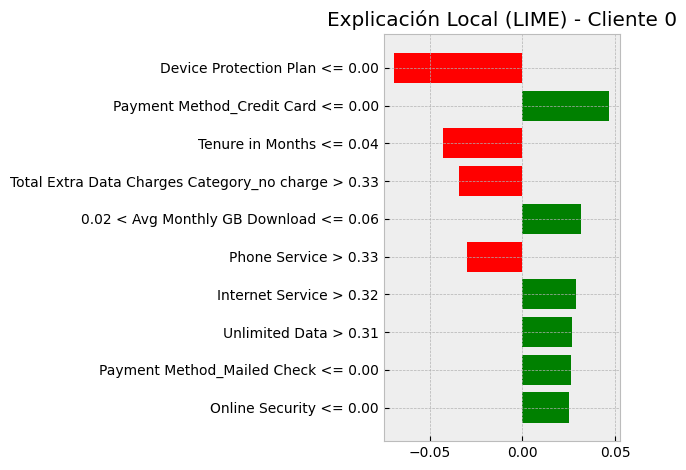

In [ ]:
# --- PASO 1: PREPARACIÓN DE DATOS ---
# Convertimos a numpy array si son DataFrames (LIME lo prefiere así)
X_train_array = X_train_selected.values if hasattr(X_train_selected, 'values') else X_train_selected
X_test_array = X_test_selected.values if hasattr(X_test_selected, 'values') else X_test_selected

# --- PASO 2: INICIALIZAR EL EXPLICADOR LIME ---
# Esto se hace una sola vez
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_array,
    feature_names=feature_names_list, # Recuperamos los nombres de las columnas
    class_names=['No Compra', 'Compra'], 
    mode='classification',
    verbose=False,
    random_state=42
)

# --- PASO 3: SELECCIONAR UN CLIENTE DE "RECHAZO" ---
# Buscamos un cliente del Top 20% (Alta Probabilidad) para ver por qué es bueno
# O uno de baja probabilidad para ver por qué es malo.

# Ejemplo: Vamos a coger el cliente que usamos en el ejemplo anterior (el 'lead ideal')
# Ojo: idx_fracaso debe ser un índice válido dentro de X_test (ej: 0, 10, 50...)
# Si no tienes uno definido, cogemos el primero del test para probar:
i = 0 

print(f"--- ANÁLISIS DEL CLIENTE (Índice {i}) ---")

# Obtenemos su probabilidad real actual
prob_real = rf.predict_proba(X_test_array[i].reshape(1, -1))[0][1]
print(f"El modelo le da un Score de: {prob_real*100:.2f}%")

# --- PASO 4: GENERAR LA EXPLICACIÓN VISUAL ---
exp = explainer.explain_instance(
    data_row=X_test_array[i], 
    predict_fn=rf.predict_proba, 
    num_features=10 
)

# Visualización en Notebook
print("\n¿Por qué tiene esta nota? (Verde = Sube nota, Rojo = Baja nota)")
display(HTML(exp.as_html(show_table=False)))

# Visualización estática (para guardar)
fig = exp.as_pyplot_figure()
plt.title(f'Explicación Local (LIME) - Cliente {i}')
plt.tight_layout()
plt.show()


--- Explicación LIME para el Cliente 1176 (Probabilidad Baja - RECHAZO) ---
Probabilidad real según RF: 0.00%
Intercept 0.4109975679337875
Prediction_local [0.26759712]
Right: 0.0


c:\Users\Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


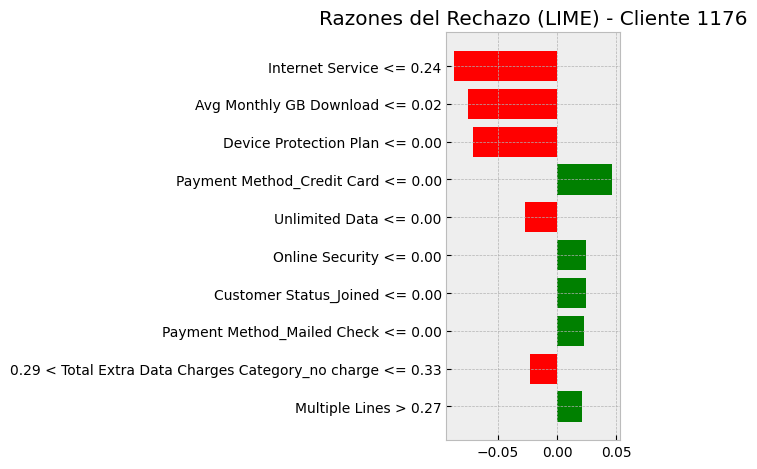

In [ ]:
# Convertimos a numpy array si son DataFrames (LIME lo prefiere así)
X_train_array = X_train_selected.values if hasattr(X_train_selected, 'values') else X_train_selected
X_test_array = X_test_selected.values if hasattr(X_test_selected, 'values') else X_test_selected

# 2. Preparamos los arrays para LIME
X_train_array = np.array(X_train_selected)
X_test_array = np.array(X_test_selected)

# 3. Inicializamos LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_array,
    feature_names=feature_names_list,
    class_names=['No Compra', 'Compra'], 
    mode='classification',
    verbose=True,
    random_state=42
)

# 4. Seleccionamos el cliente de RECHAZO
i = idx_fracaso 
print(f"\n--- Explicación LIME para el Cliente {i} (Probabilidad Baja - RECHAZO) ---")

# Verificamos la probabilidad real
prob = rf.predict_proba(X_test_array[i].reshape(1, -1))[0][1]
print(f"Probabilidad real según RF: {prob*100:.2f}%")

# 5. Generamos la explicación
exp = explainer.explain_instance(
    data_row=X_test_array[i], 
    predict_fn=rf.predict_proba, 
    num_features=10 
)

# 6. Visualización
display(HTML(exp.as_html(show_table=True)))

fig = exp.as_pyplot_figure()
plt.title(f'Razones del Rechazo (LIME) - Cliente {i}')
plt.tight_layout()
plt.show()

El análisis local mediante LIME del caso de rechazo del Cliente 1176 permite identificar con precisión las reglas de exclusión que aplica el modelo Random Forest. A diferencia de SHAP, que cuantifica la magnitud del impacto de cada variable, LIME explicita las condiciones lógicas concretas que fuerzan la probabilidad de compra a valores prácticamente nulos.

**Factores que bloquean la compra (contribuciones negativas)**

Las barras rojas reflejan condiciones que inhiben de forma directa la contratación:

- Infraestructura inexistente (Internet Service ≤ 0.24):
Este factor presenta el mayor impacto negativo. El valor real del cliente es 0.00, lo que indica ausencia total de servicio de internet. El modelo establece una regla crítica: sin conectividad, la venta de un servicio de streaming es técnicamente inviable, aplicando una penalización máxima.

- Ausencia de huella digital:
Las condiciones Device Protection Plan ≤ 0.00 y Avg Monthly GB Download ≤ 0.02 actúan como bloqueos estructurales. El cliente no muestra consumo de datos ni protección de dispositivos, lo que lleva al modelo a clasificarlo como un perfil “analógico” o desconectado, incompatible con el producto.

- Perfil de consumo pasivo:
La variable Total Extra Data Charges Category – no charge aparece también con contribución negativa. El modelo penaliza a los usuarios que nunca exceden sus límites de consumo, priorizando perfiles con mayor intensidad de uso y propensión a servicios adicionales.

**Factores con impacto irrelevante (contribuciones positivas menores)**

Aunque se observan pequeñas contribuciones positivas (por ejemplo, cierta antigüedad o métodos de pago alternativos), su efecto es insuficiente para compensar las barreras técnicas detectadas previamente.

**Conclusión de negocio**

Este caso confirma que el modelo opera bajo una lógica de “requisitos mínimos”: cuando un cliente incumple condiciones básicas de infraestructura (conectividad) y actividad digital (uso de datos), la probabilidad de compra se descarta automáticamente, independientemente de otros atributos favorables como la antigüedad.

--- Explicación LIME para el Cliente 375 (Alta Probabilidad - ÉXITO) ---
Probabilidad real según RF: 99.00%
Intercept 0.34535914701040293
Prediction_local [0.50184554]
Right: 0.99


c:\Users\Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


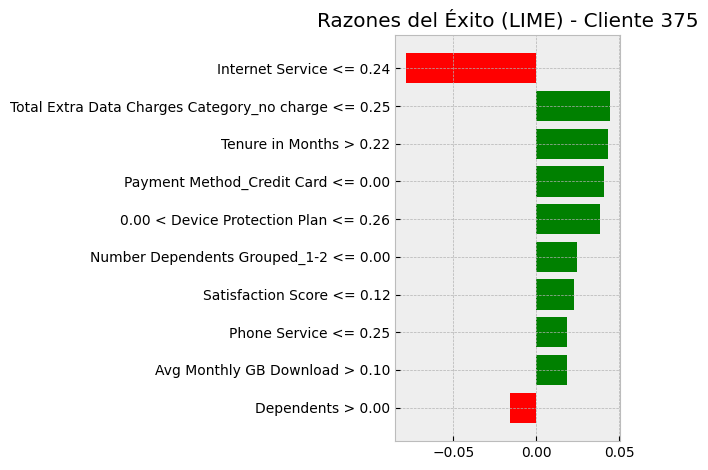

In [ ]:
# 1. Seleccionamos el cliente EXITOSO (Calculado previamente con SHAP)
i = idx_exito 

print(f"--- Explicación LIME para el Cliente {i} (Alta Probabilidad - ÉXITO) ---")

# Verificamos la probabilidad real
prob = rf.predict_proba(X_test_array[i].reshape(1, -1))[0][1]
print(f"Probabilidad real según RF: {prob*100:.2f}%")

# 2. Generamos la explicación
exp = explainer.explain_instance(
    data_row=X_test_array[i], 
    predict_fn=rf.predict_proba, 
    num_features=10 
)

# 3. Visualización (Con el parche para evitar el error de display)
display(HTML(exp.as_html(show_table=True)))

# 4. Gráfico de Barras
fig = exp.as_pyplot_figure()
plt.title(f'Razones del Éxito (LIME) - Cliente {i}')
plt.tight_layout()
plt.show()

El análisis local con LIME permite descomponer esta decisión y entender qué factores concretos están impulsando el resultado.

**Factores que impulsan la compra (contribuciones positivas)** 

Las barras verdes representan variables que incrementan la probabilidad de compra:

- Antigüedad elevada (Tenure in Months > 0.22): Un mayor tiempo como cliente refuerza la confianza y la propensión a contratar nuevos servicios.

- Ausencia de cargos extra por datos (Total Extra Data Charges Category = “no charge”): La percepción de control de costes actúa como un fuerte incentivo.

- Contratación de Device Protection Plan (0.00 < Device Protection Plan ≤ 0.26) : Indica un perfil más comprometido con el ecosistema de servicios.

- Uso medio-alto de datos (Avg Monthly GB Download > 0.10): Refuerza el perfil tecnológico y la necesidad del servicio.

- Métodos de pago no tradicionales (Payment Method ≠ Credit Card / ≠ Mailed Check): Asociados históricamente a mayor conversión.

Nivel aceptable de satisfacción (Satisfaction Score ≤ 0.12): Aunque no extremo, contribuye positivamente al resultado final.

**Factores que reducen la probabilidad (contribuciones negativas)**

Las barras rojas muestran elementos que juegan en contra, aunque con impacto limitado:

- Tipo de servicio de internet (Internet Service ≤ 0.24): Este atributo introduce una penalización moderada, indicando que el servicio contratado no es el óptimo para maximizar la probabilidad de compra. No obstante, su efecto es claramente compensado por otros drivers clave.

- Número de dependientes (Dependents > 0.00): La presencia de dependientes añade una ligera restricción en la propensión a contratar, pero su impacto es marginal en comparación con las señales de fidelización y uso del servicio.

**Conclusión de negocio**

El modelo aplica una lógica coherente y alineada con la realidad comercial: prioriza la fidelización, el uso intensivo del servicio y la estabilidad del cliente frente a factores secundarios.
Este caso confirma que la predicción no es arbitraria, sino el resultado de una combinación consistente de señales de alto valor, lo que refuerza la confianza en el modelo y su explicabilidad.

### Explicabilidad agrupada

La explicabilidad agrupada nos permite ver patrones generales en los clientes, mostrando qué características impulsan o frenan la contratación de servicios. En lugar de mirar caso por caso, destaca las tendencias globales, como la importancia de la infraestructura digital, el consumo de datos y los servicios adicionales, y cómo estas variables interactúan de manera consistente para explicar las decisiones del modelo.muestra, de forma resumida, qué características impulsan o frenan la contratación, revelando patrones globales consistentes en el modelo.

#### Clustering de los shapley values

El clustering de Shapley Values agrupa clientes con comportamientos de predicción similares, ayudando a identificar perfiles tipo dentro de la base de datos.

Calculando inercia para K-Means...


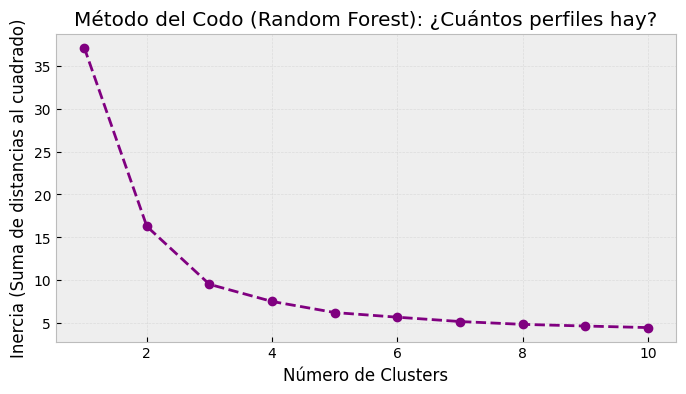

In [43]:
# 1. PREPARACIÓN DE DATOS
# Random Forest devuelve una lista [Clase0, Clase1]. 
# Necesitamos la matriz de la Clase 1 (Compra) para hacer los grupos.

if isinstance(shap_values, list):
    # Formato lista: [Matriz_No_Compra, Matriz_Compra]
    shap_data = shap_values[1]
elif len(shap_values.shape) == 3:
    # Formato array 3D: (samples, features, classes)
    shap_data = shap_values[:, :, 1]
else:
    # Si ya lo habías filtrado antes
    shap_data = shap_values

# Aseguramos que sea un array de numpy limpio
shap_data = np.array(shap_data)

# 2. MÉTODO DEL CODO
inertia_clustering_list = []
max_clust = 10

print("Calculando inercia para K-Means...")

for i in range(1, max_clust+1):
    # n_init=10 es estándar para evitar advertencias futuras
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) 
    kmeans.fit(shap_data)
    inertia_clustering_list.append(kmeans.inertia_)

# --- 3. GRAFICAR ---
plt.figure(figsize=(8, 4))
plt.plot(range(1, max_clust+1), inertia_clustering_list, marker='o', linestyle='--', color='purple')
plt.title('Método del Codo (Random Forest): ¿Cuántos perfiles hay?')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia (Suma de distancias al cuadrado)')
plt.grid(True, alpha=0.3)
plt.show()

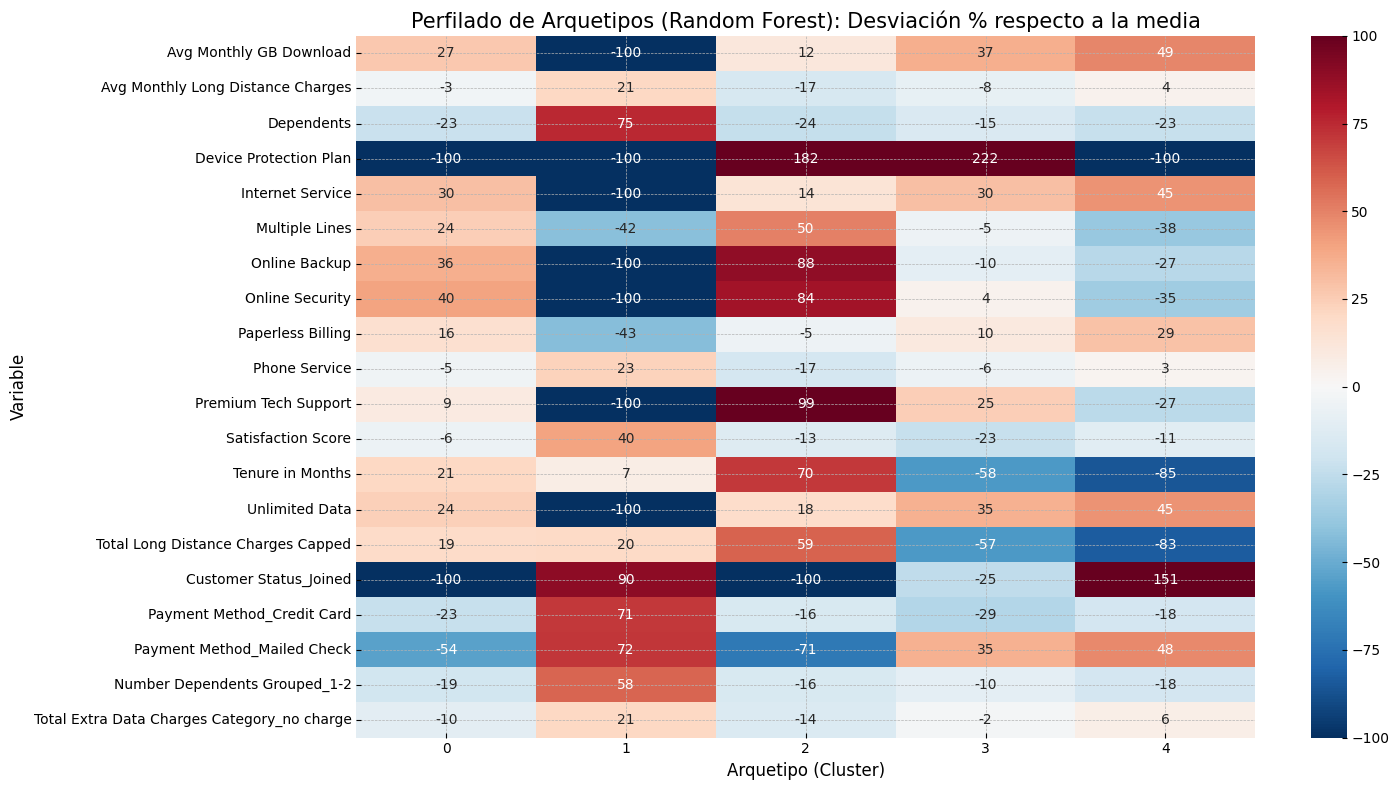

Tamaño de los clusters (Número de Clientes):
Cluster
0    337
1    318
2    325
3    153
4    276
Name: count, dtype: int64


In [44]:
# Configuración del Clustering
optimal_k = 5  # Vemos que hay 4 cluster e incluimos 1 para asegurar los grupos

# Entrenar K-Means con valores SHAP (Agrupamos por "Motivación de Compra")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(shap_data)

# Preparar DataFrame con DATOS REALES
# Reconstruimos el DataFrame por si X_test_selected se convirtió en array numpy antes
X_test_df = pd.DataFrame(X_test_selected, columns=feature_names_list)

# Creamos una copia para no alterar el original
X_test_clust = X_test_df.copy()
X_test_clust['Cluster'] = clusters

# Calcular medias y diferencias relativas
clust_mean = X_test_clust.groupby('Cluster').mean() # Media de cada cluster
global_mean = X_test_df.mean() # Media global

# Diferencia porcentual: ¿Cuánto se desvía este grupo del promedio?
# Añadimos un pequeño epsilon (1e-9) para evitar división por cero si alguna media global es 0
clust_diff_pct = (clust_mean - global_mean).div(global_mean + 1e-9).fillna(0) * 100

# 5. Visualizar Heatmap
plt.figure(figsize=(15, 8)) # Un poco más alto para que se lean bien las variables
sns.heatmap(
    clust_diff_pct.T, 
    annot=True, 
    fmt=".0f",      # Sin decimales para limpiar la vista (puedes poner .1f si prefieres)
    cmap="RdBu_r",  # Rojo = Por encima de la media, Azul = Por debajo
    center=0,
    vmax=100, vmin=-100 # Limitamos el color para que los outliers no rompan la escala
)

plt.title('Perfilado de Arquetipos (Random Forest): Desviación % respecto a la media', fontsize=15)
plt.xlabel('Arquetipo (Cluster)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# 6. Conteo de clientes por cluster
print("Tamaño de los clusters (Número de Clientes):")
counts = X_test_clust['Cluster'].value_counts().sort_index()
print(counts)

El heatmap permite traducir los datos en perfiles claros y fáciles de entender, mostrando cinco tipos de clientes muy distintos:

Usuarios muy digitales y activos: Destacan dos grupos. Por un lado, los clientes con consumo muy alto de datos y tarifas ilimitadas, normalmente recién llegados, que encajan perfectamente con el streaming. Por otro, usuarios nuevos que ya invierten en proteger sus dispositivos y consumen bastante contenido, para quienes el streaming es una extensión natural de lo que ya usan.

Clientes fieles y estables: Un grupo con mucha antigüedad y fuerte contratación de servicios de soporte y protección. No son los más intensivos en consumo, pero confían en la compañía y valoran servicios de calidad, lo que los hace buenos candidatos con un enfoque más relacional.

Usuarios equilibrados: Clientes con varios servicios digitales activos y un uso razonable de datos. No destacan en un solo punto, pero tienen una base sólida para completar su oferta con streaming.

Clientes analógicos: Un grupo claramente desconectado del entorno digital, sin internet ni consumo de datos, que no resulta adecuado para campañas de streaming.

En conjunto, la segmentación muestra que el potencial de contratación no es uniforme: los mayores esfuerzos deben centrarse en usuarios intensivos en datos y en perfiles digitales recientes, mientras que los clientes tradicionales quedan fuera del objetivo.

In [45]:
# 1. Preparación DF de SHAP con Clusters
# Asumimos que 'shap_data' y 'clusters' vienen del paso anterior (K-Means)
shap_df_clust = pd.DataFrame(shap_data, columns=feature_names_list)
shap_df_clust['Cluster'] = clusters

# Calculamos el SHAP medio por cluster (Qué importa a cada grupo)
shap_mean_per_cluster = shap_df_clust.groupby('Cluster').mean()

# 2. Probabilidad media por cluster (AQUÍ ESTÁ EL CAMBIO PARA RF)
# Usamos el Random Forest para predecir la probabilidad de éxito
probs = rf.predict_proba(X_test_selected)[:, 1]

# Actualizamos el DataFrame X_test_clust con las nuevas probabilidades
X_test_clust['Probabilidad'] = probs
stats_df = X_test_clust.groupby('Cluster')[['Probabilidad']].mean()
stats_df['Num_Clientes'] = X_test_clust['Cluster'].value_counts()

# 3. Bucle de visualización para el Pie Chart
print("Generando fichas de Arquetipos basadas en Random Forest...")

for cluster_id in range(optimal_k):
    
    # --- Datos para el Pie Chart (Contribución SHAP positiva) ---
    # Qué variables empujan el "SÍ" en este grupo específico
    top_shap = shap_mean_per_cluster.loc[cluster_id].sort_values(ascending=False).head(5) 
    top_shap_pos = top_shap[top_shap > 0] # Solo las positivas
    
    # --- Datos para la Tabla (Valores Reales vs Media) ---
    top_vars_names = top_shap.index.tolist()
    
    val_medio_cluster = clust_mean.loc[cluster_id, top_vars_names]
    dif_vs_media = clust_diff_pct.loc[cluster_id, top_vars_names]
    
    # --- Crea la figura ---
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "domain"}, {"type": "domain"}]],
        subplot_titles=[f"Motores de Compra (SHAP)", "Perfil Real vs Media Global"]
    )
    
    # 1. Crea el Pie Chart
    fig.add_trace(go.Pie(
        labels=top_shap_pos.index,
        values=top_shap_pos.values,
        textinfo="label+percent",
        insidetextorientation="radial",
        marker=dict(colors=px.colors.sequential.Tealgrn[::-1])
    ), row=1, col=1)
    
    # 2. Crea la Tabla
    fig.add_trace(go.Table(
        header=dict(
            values=["Variable", "Valor Real (Media)", "Diferencia vs Global"],
            fill_color="#27cc7f", font=dict(color='white', size=12), align="left"
        ),
        cells=dict(
            values=[
                top_vars_names,
                [f"{x:.2f}" for x in val_medio_cluster],
                [f"{x:+.1f}%" for x in dif_vs_media] # Formato con signo +/-%
            ],
            fill_color="#daf2e7", align="left"
        )
    ), row=1, col=2)
    
    # Títulos y Layout
    score_medio = stats_df.loc[cluster_id, 'Probabilidad'] * 100
    n_cli = stats_df.loc[cluster_id, 'Num_Clientes']
    
    fig.update_layout(
        title_text=f"<b>Arquetipo {cluster_id}</b> | Probabilidad Éxito: <span style='color:green'>{score_medio:.1f}%</span> | Tamaño: {n_cli} clientes",
        height=400, width=1000, showlegend=False
    )
    
    fig.show()

Generando fichas de Arquetipos basadas en Random Forest...


**Arquetipo 2: Cliente veterano con alta protección de dispositivos**

- Probabilidad de éxito: 72,5% (la más elevada).

- Factores clave (SHAP): La decisión del modelo se apoya principalmente en el Device Protection Plan (32,8%), en la antigüedad del cliente (Tenure, 20%) y en el gasto de GB de datos (Avg Monthly GB Download)

- Perfil: Clientes con una permanencia muy superior a la media y una fuerte contratación de servicios de protección de dispositivos.

- Interpretación: Se trata de un segmento altamente fidelizado, con confianza en la compañía y predisposición a contratar servicios adicionales de valor.


**Arquetipo 3: Cliente reciente con alta contratación de protección**

- Probabilidad de éxito: 52,5%.

- Factores clave (SHAP): El Device Protection Plan concentra más del 50% del peso en la decisión del modelo.

- Perfil: Clientes de incorporación reciente, con una contratación de protección de dispositivos muy superior a la media y un consumo de datos relevante.

- Interpretación: Usuarios que han realizado una inversión reciente en tecnología y muestran interés en maximizar el uso de sus dispositivos mediante servicios digitales.

**Arquetipo 4: Usuario intensivo de datos**

- Probabilidad de éxito: 29,6%.

- Factores clave (SHAP): El consumo medio mensual de datos (Avg Monthly GB Download) explica cerca del 58% de la decisión.

- Perfil: Clientes con un uso muy elevado de datos y alta presencia de tarifas ilimitadas, pero con menor interés en servicios de seguridad.

- Interpretación: Segmento caracterizado por un consumo intensivo, donde la capacidad y el volumen de datos son los principales impulsores del interés por el streaming.

**Arquetipo 0: Cliente digital equilibrado**

- Probabilidad de éxito: 49,3%.

- Factores clave (SHAP): Combinación de consumo de datos, servicio de internet y antigüedad.

- Perfil: Clientes con valores consistentemente por encima de la media en varias dimensiones, sin destacar de forma extrema en ninguna.

- Interpretación: Segmento estable y homogéneo, con una base digital sólida y sin barreras claras para la contratación del servicio.

**Arquetipo 1: Cliente con baja digitalización**

- Probabilidad de éxito: 0,1%.

- Factores clave (SHAP): La ausencia de servicios digitales, como seguridad online, actúa como freno principal.

- Perfil: Clientes con métodos de pago tradicionales y sin infraestructura digital relevante.

- Interpretación: Segmento que no dispone de las condiciones técnicas necesarias para la contratación del servicio analizado.

**Síntesis**

Los resultados muestran que la propensión a contratar Streaming Movies varía notablemente entre arquetipos. Los perfiles con mayor fidelización y contratación de servicios de valor añadido presentan las probabilidades más altas, mientras que los clientes con bajo nivel de digitalización quedan claramente fuera del público objetivo. Esta segmentación permite orientar estrategias diferenciadas según el perfil y el potencial de cada grupo.

## Métricas

En este apartado se traducen las métricas técnicas y de explicabilidad del modelo a indicadores de negocio comprensibles y accionables, con el objetivo de evaluar su impacto real y potencial.

### Probabilidad de conversión de cada lead y top 20%

Generamos un propensity score individual entre 0 y 1, que nos permitirá clasificar leads y poder seleccionar el top 20%.

In [46]:
# --- PASO 1: RECUPERAR LOS DATOS ORIGINALES (FEATURES) ---
if isinstance(X_test_selected, pd.DataFrame):
    df_completo = X_test_selected.copy()
else:
    df_completo = pd.DataFrame(X_test_selected, columns=feature_names_list)

# --- PASO 2: AÑADIR LA INTELIGENCIA ARTIFICIAL (VARIABLES EN INGLÉS) ---

# A) Propensity Score (Probabilidad)
df_completo['Propensity_Score'] = rf.predict_proba(X_test_selected)[:, 1]

# B) Model Prediction (Predicción 0 o 1)
df_completo['Model_Prediction'] = rf.predict(X_test_selected)

# C) Actual Value (Dato Real)
# Usamos .values para asegurar que encaje bien
df_completo['Actual_Value'] = y_test_norm.values 

# --- PASO 3: SEGMENTACIÓN DE NEGOCIO ---

# Calculamos el corte del Top 20%
corte_20 = df_completo['Propensity_Score'].quantile(0.80)

# Creamos columna Priority
df_completo['Priority'] = np.where(
    df_completo['Propensity_Score'] >= corte_20, 
    'High (Top 20%)', 
    'Standard'
)

# --- PASO 4: ORDENAR Y RE-ORGANIZAR COLUMNAS ---

# 1. Ordenamos por probabilidad (los mejores arriba)
df_completo = df_completo.sort_values(by='Propensity_Score', ascending=False)

# 2. Definimos el orden exacto de columnas
# Primero las de gestión, luego predicción vs realidad, luego el resto
cols_gestion = ['Priority', 'Propensity_Score', 'Model_Prediction', 'Actual_Value']
cols_features = [c for c in df_completo.columns if c not in cols_gestion]

# Reordenamos el DataFrame final
df_completo = df_completo[cols_gestion + cols_features]

# --- PASO 5: VISUALIZAR Y EXPORTAR ---
print(f"Tabla final generada: {df_completo.shape[0]} filas.")
print("Primeras 5 filas (Top Leads):")
display(df_completo.head(5))

# Exportar a Excel
# df_completo.to_excel("Final_Leads_Report.xlsx", index=False)

Tabla final generada: 1409 filas.
Primeras 5 filas (Top Leads):


,Priority,Propensity_Score,Model_Prediction,Actual_Value,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Dependents,Device Protection Plan,Internet Service,Multiple Lines,Online Backup,Online Security,Paperless Billing,Phone Service,Premium Tech Support,Satisfaction Score,Tenure in Months,Unlimited Data,Total Long Distance Charges Capped,Customer Status_Joined,Payment Method_Credit Card,Payment Method_Mailed Check,Number Dependents Grouped_1-2,Total Extra Data Charges Category_no charge
375,High (Top 20%),0.99,1,1,0.197037,0.143137,0.22037,0.220370,0.220370,0.220370,0.220370,0.220370,0.220370,0.220370,0.220370,0.110185,0.220370,0.220370,0.199850,0.0,0.000000,0.0,0.0,0.220370
409,High (Top 20%),0.99,1,0,0.115602,0.029197,0.00000,0.239662,0.239662,0.239662,0.000000,0.239662,0.239662,0.239662,0.239662,0.119831,0.239662,0.239662,0.040765,0.0,0.239662,0.0,0.0,0.239662
1142,High (Top 20%),0.99,1,1,0.026266,0.046845,0.00000,0.248071,0.248071,0.248071,0.248071,0.248071,0.248071,0.248071,0.248071,0.124035,0.244577,0.248071,0.064498,0.0,0.248071,0.0,0.0,0.248071
286,High (Top 20%),0.99,1,1,0.080696,0.023326,0.00000,0.254042,0.254042,0.254042,0.254042,0.254042,0.254042,0.254042,0.254042,0.127021,0.254042,0.254042,0.032568,0.0,0.000000,0.0,0.0,0.254042
621,High (Top 20%),0.98,1,0,0.023572,0.010972,0.00000,0.250454,0.250454,0.250454,0.250454,0.000000,0.250454,0.250454,0.250454,0.125227,0.211651,0.250454,0.012979,0.0,0.250454,0.0,0.0,0.250454


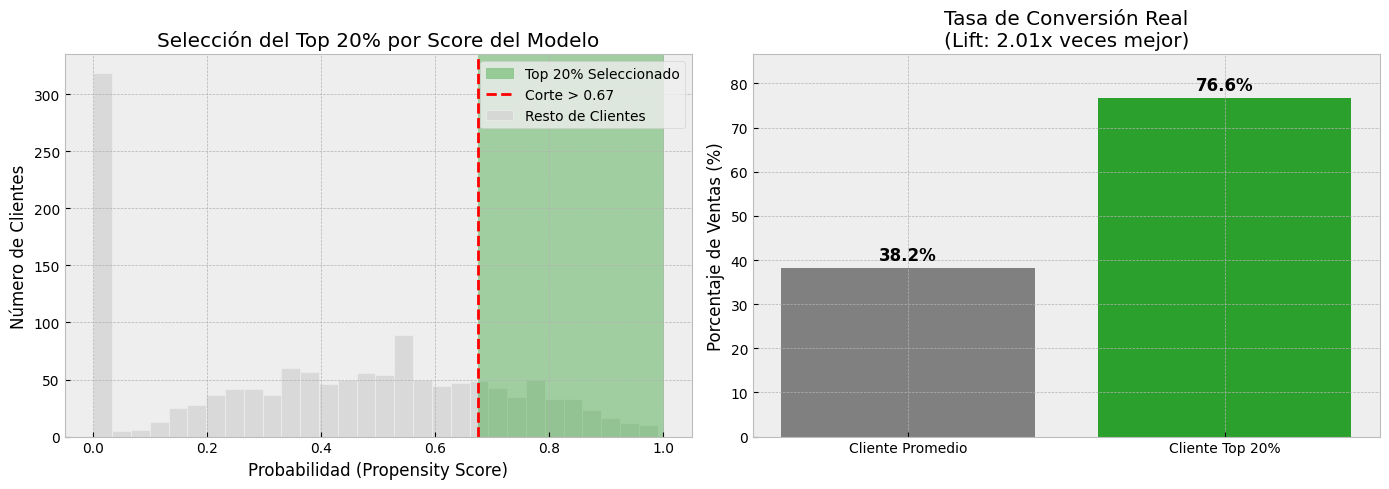

In [47]:
# 1. Definimos el corte usando la columna que ya existe
corte_20 = df_completo['Propensity_Score'].quantile(0.80)
subset_top = df_completo[df_completo['Propensity_Score'] >= corte_20]

# --- PASO 2: Figura con dos subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# GRÁFICO 1: Distribución + Top 20%
# =========================
# Usamos df_completo['Propensity_Score'] directamente
sns.histplot(
    df_completo['Propensity_Score'],
    bins=30,
    color='lightgray',
    ax=axes[0],
    label='Resto de Clientes'
)

axes[0].axvspan(
    corte_20,
    1,
    color='#2ca02c',
    alpha=0.4,
    label='Top 20% Seleccionado'
)

axes[0].axvline(
    corte_20,
    color='red',
    linestyle='--',
    label=f'Corte > {corte_20:.2f}'
)

axes[0].set_title('Selección del Top 20% por Score del Modelo')
axes[0].set_xlabel('Probabilidad (Propensity Score)')
axes[0].set_ylabel('Número de Clientes')
axes[0].legend()

# =========================
# GRÁFICO 2: Lift / Conversión
# =========================
# Usamos df_completo['Actual_Value'] directamente
tasa_global = df_completo['Actual_Value'].mean()
tasa_top_20 = subset_top['Actual_Value'].mean()
lift_20 = tasa_top_20 / tasa_global

bar_labels = ['Cliente Promedio', 'Cliente Top 20%']
bar_values = [tasa_global * 100, tasa_top_20 * 100]
colors = ['gray', '#2ca02c']

bars = axes[1].bar(bar_labels, bar_values, color=colors)

for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

axes[1].set_title(f'Tasa de Conversión Real\n(Lift: {lift_20:.2f}x veces mejor)')
axes[1].set_ylabel('Porcentaje de Ventas (%)')
axes[1].set_ylim(0, max(bar_values) + 10)

plt.tight_layout()
plt.show()

**Gráfico Izquierdo: Selección del Top 20% por Score del Modelo**

La gran mayoría de clientes tienen muy baja probabilidad de compra (barra gris) cercanos a 0 muestra. El modelo nos permite ignorarlos, ahorrando tiempo y recursos.

Solo consideramos clientes con probabilidad superior al 67% (línea roja) que son el top 20%. Gracias al modelo, los identificamos con precisión y podemos ser más selectivos a la hora de identificar el público objetivo en campañas de captación de clientes de Streaming de Películas.

**Gráfico Derecho: Impacto en Ventas**

Sin el modelo, el esfuerzo comercial tendría éxito en el 38% de los intentos. Mientras que si se enfoca solo en los clientes pertenecientes al top 20%, la tasa de cierre se eleva a 76,6%.
Esto significa que, por cada hora de trabajo del equipo comercial, cerramos el doble de ventas que antes (Lift 2.01x).

**Resumen**
En lugar de vender a ciegas, el modelo filtra a los clientes con baja probabilidad y nos permite concentrar esfuerzos en quienes realmente importan. El resultado: 3 de cada 4 impactos a la zona verde se convierten en venta, duplicando la productividad del equipo.

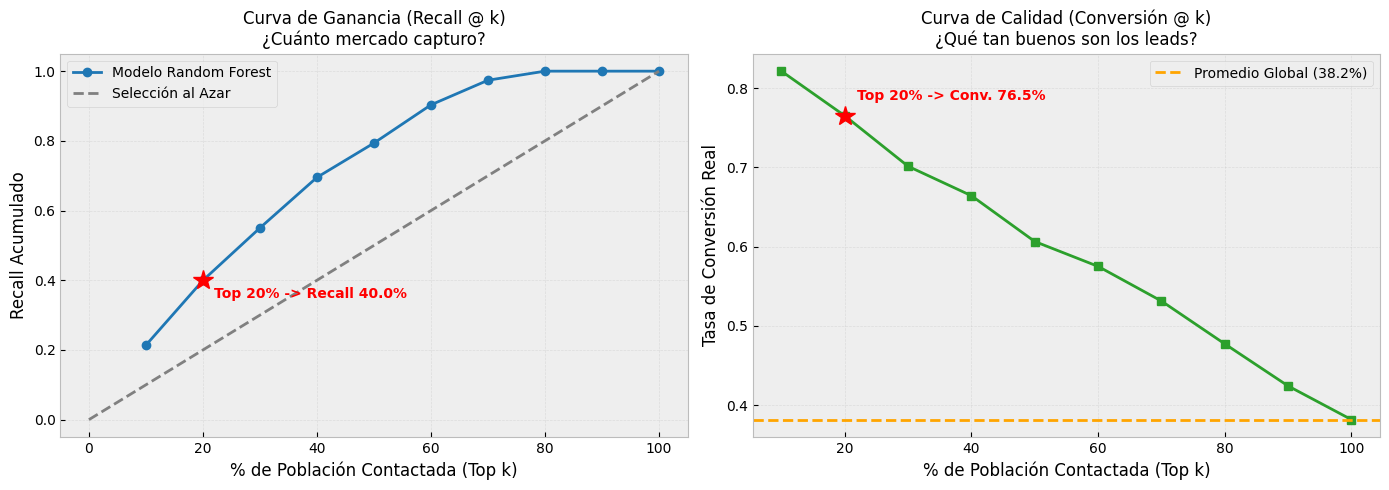

--- TABLA DE RENDIMIENTO ESTRATÉGICO ---


,Top_k_%,Recall_Acumulado,Tasa_Conversion_Real
0,10,21.4%,82.1%
1,20,40.0%,76.5%
2,30,55.0%,70.1%
3,40,69.5%,66.4%
4,50,79.4%,60.7%
5,60,90.3%,57.5%
6,70,97.4%,53.1%
7,80,100.0%,47.7%
8,90,100.0%,42.4%
9,100,100.0%,38.2%


In [48]:
# --- PASO 1: CÁLCULOS ---

# Aseguramos que el DF esté ordenado por score (por si acaso se desordenó)
df_calculos = df_completo.sort_values(by='Propensity_Score', ascending=False)

# Totales globales (Ya los tenemos en la columna Actual_Value)
total_compradores = df_calculos['Actual_Value'].sum()
total_clientes = len(df_calculos)

# Preparamos las listas
k_values = np.arange(10, 110, 10)
recall_values = []
conversion_rates = []

for k in k_values:
    # Seleccionamos el top k% usando slicing directo
    n_corte = int(total_clientes * (k / 100))
    
    # Al estar ordenado, .head(n) es exactamente el Top K%
    top_slice = df_calculos.head(n_corte)
    
    # Ventas reales en ese segmento
    ventas_en_top = top_slice['Actual_Value'].sum()
    
    # 1. Recall
    recall_values.append(ventas_en_top / total_compradores)
    
    # 2. Conversión
    conversion_rates.append(ventas_en_top / n_corte)

# --- PASO 2: VISUALIZACIÓN ---
plt.figure(figsize=(14, 5))

# === GRÁFICO 1: Curva de Recall ===
plt.subplot(1, 2, 1)
plt.plot(k_values, recall_values, marker="o", linewidth=2, color='#1f77b4', label='Modelo Random Forest')
plt.plot([0, 100], [0, 1], linestyle='--', color='gray', label='Selección al Azar') 

# Marcamos el punto del 20% (índice 1 de la lista)
idx_20 = 1 
plt.plot(20, recall_values[idx_20], marker='*', color='red', markersize=15)
plt.text(22, recall_values[idx_20]-0.05, f'Top 20% -> Recall {recall_values[idx_20]:.1%}', color='red', fontweight='bold')

plt.title("Curva de Ganancia (Recall @ k)\n¿Cuánto mercado capturo?", fontsize=12)
plt.xlabel("% de Población Contactada (Top k)")
plt.ylabel("Recall Acumulado")
plt.grid(True, alpha=0.3)
plt.legend()


# === GRÁFICO 2: Curva de Calidad (Conversión) ===
plt.subplot(1, 2, 2)
plt.plot(k_values, conversion_rates, marker="s", linewidth=2, color='#2ca02c')

# Tasa global usando el dato que ya tenemos
tasa_global = df_calculos['Actual_Value'].mean()
plt.axhline(y=tasa_global, color='orange', linestyle='--', label=f'Promedio Global ({tasa_global:.1%})')

# Marcamos el punto del 20%
plt.plot(20, conversion_rates[idx_20], marker='*', color='red', markersize=15)
plt.text(22, conversion_rates[idx_20] + 0.02, f'Top 20% -> Conv. {conversion_rates[idx_20]:.1%}', color='red', fontweight='bold')

plt.title("Curva de Calidad (Conversión @ k)\n¿Qué tan buenos son los leads?", fontsize=12)
plt.xlabel("% de Población Contactada (Top k)")
plt.ylabel("Tasa de Conversión Real")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# --- PASO 3: TABLA RESUMEN ---
print("--- TABLA DE RENDIMIENTO ESTRATÉGICO ---")
df_resumen = pd.DataFrame({
    'Top_k_%': k_values,
    'Recall_Acumulado': [f"{x:.1%}" for x in recall_values],
    'Tasa_Conversion_Real': [f"{x:.1%}" for x in conversion_rates]
})
display(df_resumen)

**Gráfico izquierdo: Curva de captura (Recall)**

Este gráfico muestra qué proporción del total de ventas potenciales se logra captar al contactar a un determinado porcentaje de clientes priorizados por el modelo. El punto clave aparece en el Top 20% de la población, donde se alcanza aproximadamente el 40% de todas las conversiones posibles. La forma claramente convexa de la curva indica que el modelo ordena de forma muy eficaz a los clientes con mayor probabilidad de compra en las primeras posiciones. En comparación con una selección aleatoria, donde sería necesario contactar al 40% de la población para lograr ese mismo nivel de captación, el modelo permite obtener el mismo resultado con la mitad del esfuerzo operativo.

**Gráfico derecho: Curva de calidad (tasa de conversión)**

Este gráfico evalúa la calidad de los clientes contactados, medida como la probabilidad media de conversión. En el Top 20%, la tasa de conversión alcanza un 76.5%, muy por encima de la media global del 38.2%. Esto implica que la mayoría de los contactos realizados en este tramo tienen una alta probabilidad de éxito. A medida que se amplía el porcentaje de población contactada, la conversión disminuye de forma progresiva, lo cual es esperable al incorporar perfiles con menor propensión. No obstante, incluso al llegar al Top 60%, la tasa de conversión sigue superando la media global, lo que demuestra que el modelo mantiene su capacidad discriminativa en una porción amplia de la base de clientes.

**Conclusión estratégica**

El análisis conjunto de ambas curvas permite ajustar la estrategia en función de los recursos disponibles. Una estrategia conservadora, centrada en el Top 10–20%, maximiza la eficiencia y es adecuada cuando el coste de contacto es elevado. Por otro lado, una estrategia más expansiva, que alcance hasta el 30–40% de la población, sigue siendo rentable: en ese rango se mantiene una conversión claramente superior a la media y se logra capturar una parte mayoritaria del mercado potencial. En consecuencia, el modelo no solo mejora la eficiencia del contacto, sino que ofrece flexibilidad operativa para equilibrar volumen y calidad según los objetivos del negocio.

### Impacto económico de las campañas

Con el fin de cuantificar el impacto económico de las campañas, calcularemos el coste y el beneficio de centrarnos en el top 20% frente a dirigirnos a todos los clientes.

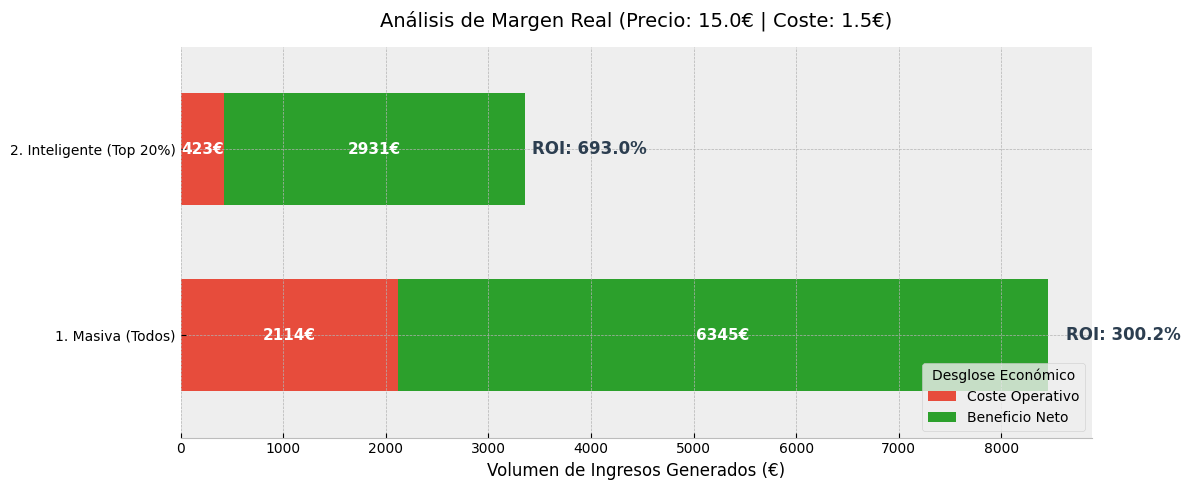

Ahorro de costes conseguido: 1690.50€


In [49]:
# --- 1. CONFIGURACIÓN Y CÁLCULOS AUTOMÁTICOS ---
PRECIO_SERVICIO = 15.0  # Ingreso por venta
COSTE_CONTACTO = 1.5    # Coste por llamada/gestión

# A) ESCENARIO MASIVO (Todos)
ingreso_total = df_completo['Propensity_Score'].sum() * PRECIO_SERVICIO
coste_total = len(df_completo) * COSTE_CONTACTO
beneficio_total = ingreso_total - coste_total
roi_total = (beneficio_total / coste_total) * 100

# B) ESCENARIO INTELIGENTE (Top 20%)
corte_20 = df_completo['Propensity_Score'].quantile(0.80)
leads_top = df_completo[df_completo['Propensity_Score'] >= corte_20]

ingreso_top = leads_top['Propensity_Score'].sum() * PRECIO_SERVICIO
coste_top = len(leads_top) * COSTE_CONTACTO
beneficio_top = ingreso_top - coste_top
roi_top = (beneficio_top / coste_top) * 100

# --- 2. PREPARACIÓN DE DATOS PARA EL GRÁFICO APILADO ---
# Creamos el DataFrame exactamente como lo necesita el gráfico horizontal
df_stack = pd.DataFrame({
    'Estrategia': ['1. Masiva (Todos)', '2. Inteligente (Top 20%)'],
    'Coste Operativo': [coste_total, coste_top],    # Parte Roja
    'Beneficio Neto': [beneficio_total, beneficio_top] # Parte Verde
})

df_stack.set_index('Estrategia', inplace=True)

# Guardamos los ROIs en una lista aparte para usarlos en las etiquetas
lista_rois = [roi_total, roi_top]

# --- 3. VISUALIZACIÓN ---
fig, ax = plt.subplots(figsize=(12, 5))

# Colores: Rojo (Coste) y Verde (Beneficio)
colors = ['#e74c3c', '#2ca02c']

# Crear gráfico apilado horizontal
df_stack.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.6)

# --- 4. ETIQUETAS Y DETALLES ---

# A) Etiquetas de Euros DENTRO de las barras
for c in ax.containers:
    # Formateamos a Euros sin decimales (.0f)
    labels = [f'{v:.0f}€' if v > 0 else '' for v in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', 
                 fontweight='bold', fontsize=11)

# B) Etiqueta de ROI a la DERECHA de las barras
# Calculamos el ancho total de cada barra (Coste + Beneficio)
totales = df_stack.sum(axis=1)

for i, (total, roi) in enumerate(zip(totales, lista_rois)):
    ax.text(total + (total*0.02), i,  # Posición X (un poco a la derecha), Posición Y
            f'ROI: {roi:.1f}%', 
            va='center', fontweight='bold', color='#2c3e50', fontsize=12)

# Títulos y limpieza visual
plt.title(f'Análisis de Margen Real (Precio: {PRECIO_SERVICIO}€ | Coste: {COSTE_CONTACTO}€)', fontsize=14, pad=15)
plt.xlabel('Volumen de Ingresos Generados (€)')
plt.ylabel('') # Quitamos etiqueta redundante
plt.legend(title='Desglose Económico', loc='lower right')

# Quitamos bordes innecesarios
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

# Imprimimos el resumen numérico por si acaso
print(f"Ahorro de costes conseguido: {coste_total - coste_top:.2f}€")

La estrategia masiva implica un coste elevado (2.114€) en llamadas poco efectivas, mientras que la estrategia inteligente reduce este gasto a solo 423€, minimizando el riesgo financiero.
Aunque la estrategia masiva genera ingresos, su eficiencia es limitada (300%). La estrategia inteligente, en cambio, alcanza un ROI del 693%, más del doble de eficiente, maximizando el rendimiento de cada euro invertido.

C:\Users\Cristina\AppData\Local\Temp\ipykernel_11308\1824586236.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




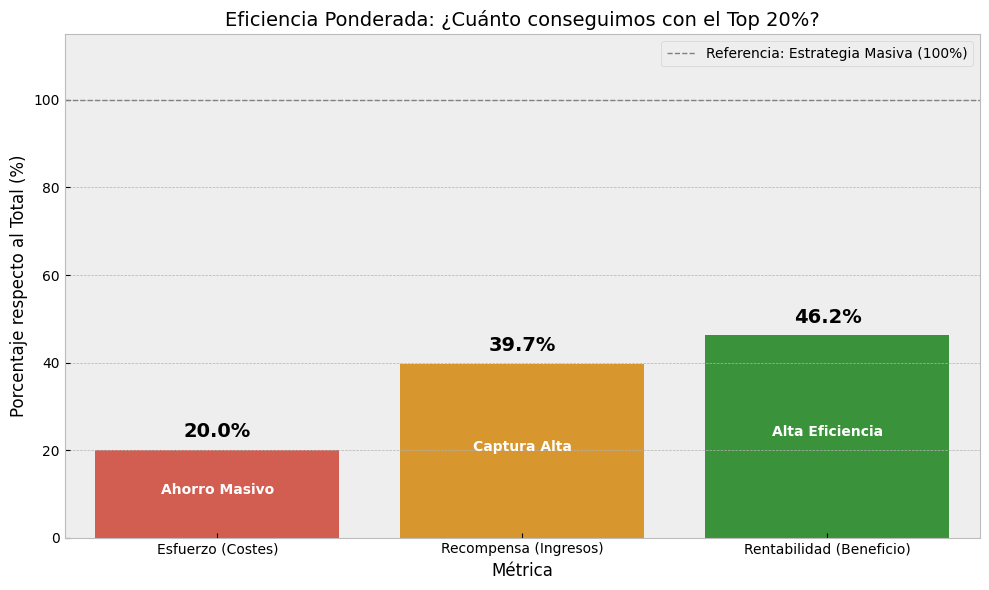

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. CONFIGURACIÓN Y CÁLCULOS ---
PRECIO_SERVICIO = 15.0
COSTE_CONTACTO = 1.5

# A) TOTALES (Referencia 100%)
ingreso_total = df_completo['Propensity_Score'].sum() * PRECIO_SERVICIO
coste_total = len(df_completo) * COSTE_CONTACTO
beneficio_total = ingreso_total - coste_total

# B) TOP 20% (Tu estrategia)
corte_20 = df_completo['Propensity_Score'].quantile(0.80)
leads_top = df_completo[df_completo['Propensity_Score'] >= corte_20]

ingreso_top = leads_top['Propensity_Score'].sum() * PRECIO_SERVICIO
coste_top = len(leads_top) * COSTE_CONTACTO
beneficio_top = ingreso_top - coste_top

# C) CÁLCULO DE PORCENTAJES (PONDERACIÓN)
# ¿Qué % del total representa el Top 20?
pct_coste = (coste_top / coste_total) * 100
pct_ingreso = (ingreso_top / ingreso_total) * 100

# El beneficio es delicado: si el total es negativo y el top es positivo, el % no tiene sentido.
# Hacemos una gestión de seguridad:
if beneficio_total > 0:
    pct_beneficio = (beneficio_top / beneficio_total) * 100
    label_beneficio = f"{pct_beneficio:.1f}% del Beneficio Total"
else:
    # Si la masiva da pérdidas y la IA da ganancias, no se puede calcular % simple
    # Lo forzamos visualmente a algo que destaque
    pct_beneficio = 100 
    label_beneficio = "¡De Pérdidas a Ganancias!"

# --- 2. PREPARAR DATOS PARA GRÁFICO ---
df_pct = pd.DataFrame({
    'Métrica': ['Esfuerzo (Costes)', 'Recompensa (Ingresos)', 'Rentabilidad (Beneficio)'],
    'Porcentaje': [pct_coste, pct_ingreso, pct_beneficio],
    'Color': ['#e74c3c', '#f39c12', '#2ca02c'] # Rojo (bajo es bueno), Naranja, Verde
})

# --- 3. VISUALIZACIÓN ---
plt.figure(figsize=(10, 6))

# Dibujamos línea de referencia del 100% (Estrategia Masiva)
plt.axhline(y=100, color='gray', linestyle='--', linewidth=1, label='Referencia: Estrategia Masiva (100%)')

# Dibujamos las barras del Top 20%
bars = sns.barplot(data=df_pct, x='Métrica', y='Porcentaje', palette=df_pct['Color'].tolist())

# Textos y Etiquetas
for bar, pct in zip(bars.patches, df_pct['Porcentaje']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height + 2, 
        f'{pct:.1f}%', 
        ha='center', va='bottom', fontweight='bold', fontsize=14
    )

plt.title('Eficiencia Ponderada: ¿Cuánto conseguimos con el Top 20%?', fontsize=14)
plt.ylabel('Porcentaje respecto al Total (%)')
plt.ylim(0, 115) # Un poco más de 100 para que quepa el texto
plt.legend()

# Explicación visual en el gráfico
plt.text(0, pct_coste/2, "Ahorro Masivo", ha='center', color='white', fontweight='bold')
plt.text(1, pct_ingreso/2, "Captura Alta", ha='center', color='white', fontweight='bold')
plt.text(2, pct_beneficio/2, "Alta Eficiencia", ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

**Eficiencia de costes:** Con el Top 20% de clientes, solo se utiliza el 20% del presupuesto total, reduciendo significativamente el gasto frente a la estrategia masiva.

**Eficiencia en ingresos:** A pesar de gastar mucho menos, se captura el 39,7% de la facturación total, casi la mitad de los ingresos posibles.

**Conclusión:** El Top 20% permite casi la mitad de los ingresos con solo una quinta parte del esfuerzo, combinando eficiencia y rentabilidad de manera óptima.